In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bond_output.csv to bond_output (3).csv


## Introduction

### Research Question

Our research question was as follows:

Can bond characteristics such as credit rating, default risk, coupon rate, and market liquidity be used to forecast bond defaults? If so, which factors are the most predictive?

### Hypotheses

#### Primary Predictive Hypothesis (General):

H1: Bond characteristics such as credit rating, coupon rate, duration, market spread, and issuance size are significant predictors of corporate bond defaults.


#### Variable-Specific Hypotheses:

H2: Bonds with lower credit ratings (e.g., speculative grade) are more likely to default than those with higher credit ratings (investment grade).

H3: Bonds with higher coupon rates are more likely to default, reflecting the increased risk premium demanded by investors.

H4: Bonds with lower issuance amounts are more prone to default, potentially indicating weaker financial standing of the issuer.

H5: Bonds with higher market spreads and lower trading volume are more likely to default, due to illiquidity and market uncertainty.

H6: Bonds with higher yields to maturity (YTM) are more likely to default, as elevated yields reflect higher perceived risk by the market.

H7: Bonds closer to maturity (shorter time-to-maturity) show an elevated likelihood of default, possibly reflecting issuers’ inability to refinance or repay obligations.



### Data Sourcing Overview

We used the Wharton Research Data Services (WRDS) Bond Database, which is a specialized and refined resource offered through Penn that is designed for U.S. corporate bond research. It integrates data from two key sources: FINRA’s TRACE (Trade Reporting and Compliance Engine), which captures bond transaction details, and Mergent FISD, which provides information on bond issues and issuer characteristics. The database is structured to allow for efficient and comprehensive analysis of corporate bond markets for researchers like us.
This dataset compiles corporate bond data from January 1st, 2003, to December 31st, 2023 (a 21-year time span) for the 30 major companies currently listed in the Dow Jones Industrial Average (DJIA) – a widely recognized index of blue-chip stocks.

Included Companies: I3M, American Express, Amgen, Amazon, Apple, Boeing, Caterpillar, Chevron, Cisco, Coca-Cola, Disney, Goldman Sachs, Home Depot, Honeywell, IBM, Johnson & Johnson, JPMorgan Chase, McDonald's, Merck, Microsoft, Nike, Nvidia, Procter & Gamble, Salesforce, Sherwin-Williams, Travelers, UnitedHealth Group, Verizon, Visa, Walmart.


### Real World Significance of Study

Through studies such as this one, there are benefits for a variety of important stakeholders. For example, investors can assess risk more accurately and optimize portfolios, and regulators can set capital requirements for financial institutions. Furthermore, bond issuers can improve bond appeal (reducing borrowing costs) and credit rating agencies can enhance rating models with data. And finally, researchers and academics can advance and contribute to existing and new literature surrounding credit risk theory, portfolio management, and bond markets, as well as the application of data sciences techniques to these subfields of finance.

#1. Data Acquisition and Preparation


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score)
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, classification_report, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay)


df = pd.read_csv("bond_output.csv")
print("\nAvailable Columns in Dataset:")
print(df.columns.tolist())

# Define potential date columns
date_columns = ["DATE", "offering_date", "maturity", "dated_date",
                "first_interest_date", "last_interest_date", "default_date",
                "reinstated_date", "nextcoup"]

# Keep only date columns that actually exist in dataset
existing_date_columns = [col for col in date_columns if col in df.columns]

# Reload dataset with only existing date columns parsed
df = pd.read_csv("bond_output.csv", parse_dates=existing_date_columns)

# Display info after parsing dates
print("\nDataset Overview After Parsing Dates:\n")
print(df.info())
df.to_csv("bond_output_cleaned.csv", index = False)
print("\nCleaned dataset saved as 'bond_output_cleaned.csv'.")

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include = ['object']).columns.tolist()
numerical_cols = df.select_dtypes(include = ['float64', 'int64']).columns.tolist()

# Encode categorical variables using Label Encoding (keeping NaNs)
print("\nEncoding Categorical Variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)  # Convert to string to handle NaNs
    df[col] = df[col].apply(lambda x: np.nan if x.lower() == 'nan' else x)  # Preserve NaNs
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Store encoders for reference

# Normalize numerical features (keep NaNs intact)
print("\nNormalizing Numerical Features...")
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("\nFinal Dataset Overview:")
print(df.info())

# Save final cleaned dataset without filling missing values
df.to_csv("bond_output_final_cleaned.csv", index = False)
print("\nFinal cleaned dataset saved as 'bond_output_final_cleaned.csv'.")

<ipython-input-125-e4ddd0d7050e>:7: DtypeWarning: Columns (15,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bond_output.csv")



Available Columns in Dataset:
['DATE', 'ISSUE_ID', 'CUSIP', 'bond_sym_id', 'bsym', 'ISIN', 'company_symbol', 'BOND_TYPE', 'SECURITY_LEVEL', 'CONV', 'OFFERING_DATE', 'OFFERING_AMT', 'OFFERING_PRICE', 'PRINCIPAL_AMT', 'MATURITY', 'TREASURY_MATURITY', 'COUPON', 'DAY_COUNT_BASIS', 'DATED_DATE', 'FIRST_INTEREST_DATE', 'LAST_INTEREST_DATE', 'NCOUPS', 'AMOUNT_OUTSTANDING', 'R_SP', 'R_MR', 'R_FR', 'N_SP', 'N_MR', 'N_FR', 'RATING_NUM', 'RATING_CAT', 'RATING_CLASS', 'T_DATE', 'T_Volume', 'T_DVolume', 'T_Spread', 'T_Yld_Pt', 'YIELD', 'PRICE_EOM', 'PRICE_LDM', 'PRICE_L5M', 'GAP', 'coupmonth', 'nextcoup', 'COUPAMT', 'COUPACC', 'MULTICOUPS', 'RET_EOM', 'RET_LDM', 'RET_L5M', 'TMT', 'REMCOUPS', 'DURATION', 'DEFAULTED', 'DEFAULT_DATE', 'DEFAULT_TYPE', 'REINSTATED', 'REINSTATED_DATE']


<ipython-input-125-e4ddd0d7050e>:20: DtypeWarning: Columns (15,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bond_output.csv", parse_dates=existing_date_columns)



Dataset Overview After Parsing Dates:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158440 entries, 0 to 158439
Data columns (total 58 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE                 158440 non-null  datetime64[ns]
 1   ISSUE_ID             158440 non-null  int64         
 2   CUSIP                158440 non-null  object        
 3   bond_sym_id          158387 non-null  object        
 4   bsym                 0 non-null       float64       
 5   ISIN                 158420 non-null  object        
 6   company_symbol       158387 non-null  object        
 7   BOND_TYPE            158440 non-null  object        
 8   SECURITY_LEVEL       158311 non-null  object        
 9   CONV                 158440 non-null  int64         
 10  OFFERING_DATE        158440 non-null  object        
 11  OFFERING_AMT         158440 non-null  int64         
 12  OFFERING_PRICE       155764 non-

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count



Final Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158440 entries, 0 to 158439
Data columns (total 58 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE                 158440 non-null  datetime64[ns]
 1   ISSUE_ID             158440 non-null  float64       
 2   CUSIP                158440 non-null  int64         
 3   bond_sym_id          158440 non-null  int64         
 4   bsym                 0 non-null       float64       
 5   ISIN                 158440 non-null  int64         
 6   company_symbol       158440 non-null  int64         
 7   BOND_TYPE            158440 non-null  int64         
 8   SECURITY_LEVEL       158440 non-null  int64         
 9   CONV                 158440 non-null  float64       
 10  OFFERING_DATE        158440 non-null  int64         
 11  OFFERING_AMT         158440 non-null  float64       
 12  OFFERING_PRICE       155764 non-null  float64  

#2. Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv("bond_output_final_cleaned.csv")

# Make column names lowercase for consistency
df.columns = df.columns.str.strip().str.lower()

# Convert 'defaulted' to string and check for unique values
if "defaulted" in df.columns:
    df["defaulted"] = df["defaulted"].astype(str)
    print("\nUnique values in 'defaulted' column:", df["defaulted"].unique())
else:
    raise KeyError("'defaulted' column not found in dataset!")

# Summary stats for numerical columns
print("\nDescriptive Statistics for Numerical Variables:")
print(df.describe())

# Count of defaulted vs. non-defaulted bonds
default_counts = df["defaulted"].value_counts()
print("\nDefaulted vs. Non-Defaulted Counts:\n", default_counts)


Unique values in 'defaulted' column: ['0' '1' '2']


The dataset consists of 158,440 corporate bond issuances from Dow Jones companies, with a notable imbalance in default status. The vast majority of bonds (157,981 or 99.7%) did not default, while 416 bonds (0.26%) were marked as defaulted (1), and 43 bonds (0.03%) fell into an additional default category (2). This distribution highlights the rarity of corporate bond defaults within blue-chip firms, reinforcing the expectation that issuers in this dataset generally maintain high creditworthiness. However, the presence of defaults, even within this select group, suggests that certain financial or structural factors contributed to distress in some cases, warranting deeper investigation.

Key characteristics of the bonds reveal significant variability. Coupon rates range widely, indicating the presence of both standard interest-bearing bonds and zero-coupon bonds. Similarly, time to maturity (TMT) varies across issuances, with some bonds having very short durations while others extend over multiple years. The dataset also includes a mix of investment-grade and lower-rated bonds, as evidenced by the variation in the rating_num field, which will be essential in determining whether credit ratings are an effective predictor of default risk. Additionally, the offering amounts and amount outstanding values show a broad spectrum, suggesting that some issuers have repurchased or retired portions of their debt over time.

The dataset also contains insights into default dynamics. The default_date field, populated for only a small subset of bonds, aligns with the dataset’s low overall default rate. Meanwhile, the reinstated column indicates that some bonds initially classified as defaulted were later reinstated, potentially due to restructuring or successful financial recoveries. This raises important questions about how default is defined in the dataset – whether it reflects only missed payments or broader financial distress resolved through negotiation.

Given the extreme imbalance in default outcomes, any predictive modeling will need to account for the rarity of defaults, potentially through oversampling methods or anomaly detection techniques. Additionally, while traditional credit ratings provide a risk assessment, further analysis is necessary to determine whether market-based indicators – such as yield spreads, issuance size, or changes in coupon rates – offer stronger predictive power. The next step will be to explore different machine learning models to evaluate whether bond characteristics can reliably forecast defaults.

###Default Rate Trends

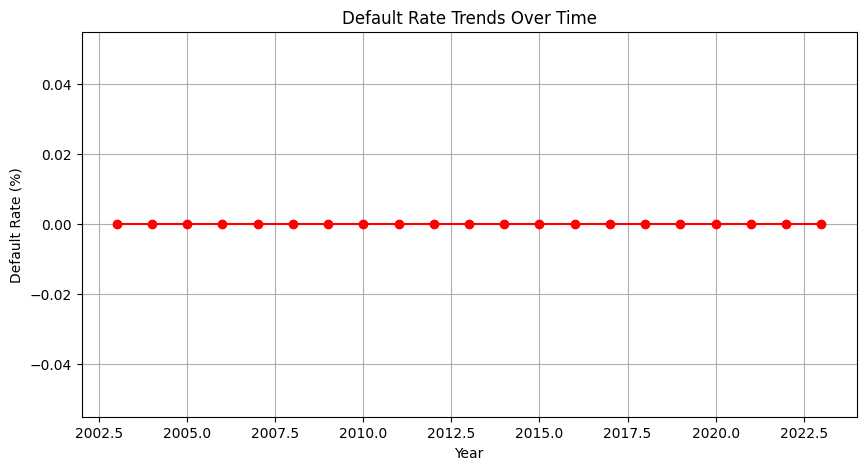

In [ ]:
# Convert DATE column to datetime and extract year
df["year"] = pd.to_datetime(df["date"]).dt.year

# Yearly default rate
default_trend = df.groupby("year")["defaulted"].apply(lambda x: (x == "Y").mean())
plt.figure(figsize = (6, 3))
plt.plot(default_trend.index, default_trend.values, marker = "o", linestyle = "-", color = "red")
plt.title("Default Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Default Rate (%)")
plt.grid(True)
plt.show()
print()

The plot displays the yearly default rate trend for bonds issued by Dow Jones companies over the period 2003–2023. However, the default rate appears to be consistently near zero throughout the entire time span, suggesting that defaults within this dataset are extremely rare or evenly distributed over time.

This flat trend raises a few explanations. First, it is possible that the dataset primarily contains investment-grade bonds from highly creditworthy issuers, making defaults inherently uncommon. Second, the lack of variation in the default rate might indicate that defaults were concentrated in a few specific years rather than occurring gradually. If this is the case, grouping data by months or quarters instead of years may reveal more meaningful fluctuations. Additionally, the dataset’s imbalance in defaulted vs. non-defaulted bonds (less than 0.3% default rate overall) may be influencing the visualization.

To gain better insights, it may be beneficial to analyze default rate trends by credit rating or sector-specific trends. This could help identify whether defaults were more common among lower-rated bonds or specific industries. Alternatively, a rolling default rate (e.g., 3-year or 5-year rolling averages) may provide a smoother representation of trends over time.

Given the low observed default rates, further modeling will likely require oversampling methods or alternative classification approaches to ensure that predictions are meaningful. The next step should involve decomposing default rates by bond characteristics to determine whether specific financial metrics – such as coupon rates, maturity, or issuance amounts – correlate with default risk.









###Bond Characteristics and Default Rates

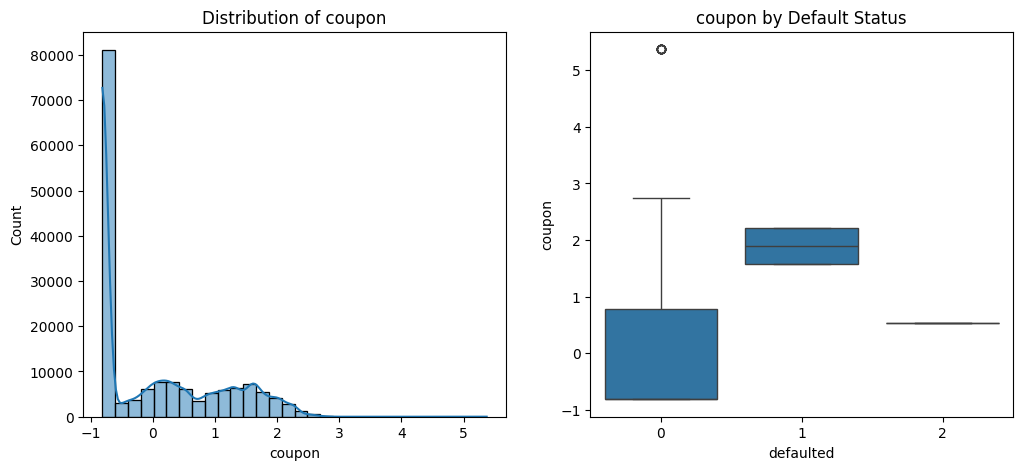

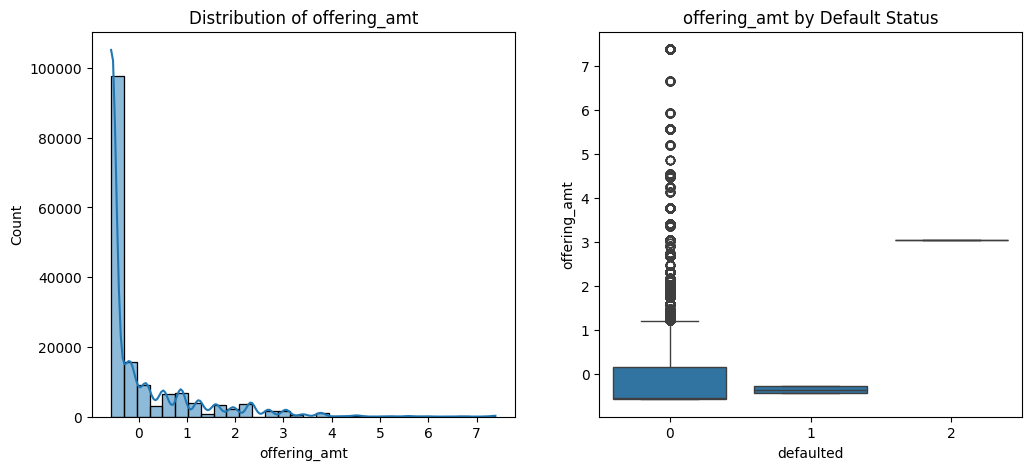

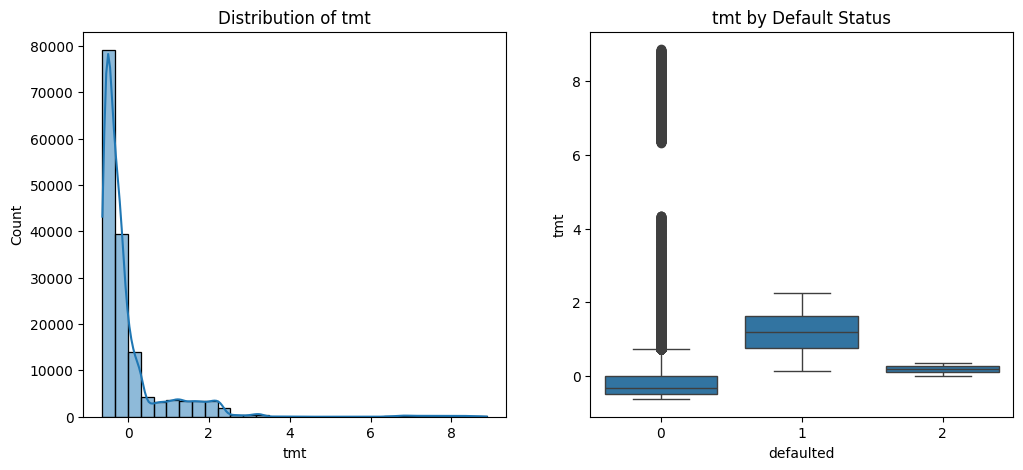

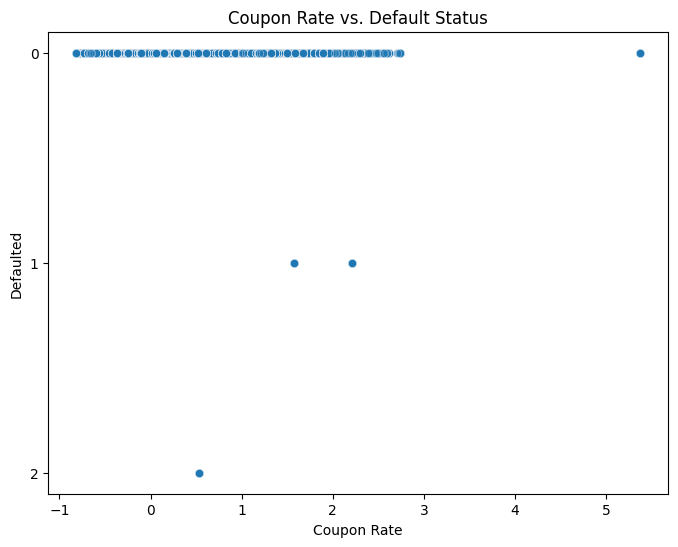

In [ ]:
features = ["coupon", "offering_amt", "tmt"]
for feature in features:
    plt.figure(figsize = (9, 4))
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], bins = 30, kde = True)
    plt.title(f"Distribution of {feature}")

    # Boxplot by default status
    plt.subplot(1, 2, 2)
    sns.boxplot(x = df["defaulted"], y = df[feature])
    plt.title(f"{feature} by Default Status")

    plt.show()
    print()

# Scatterplots to visualize relationships
plt.figure(figsize = (6, 4))
sns.scatterplot(x = df["coupon"], y = df["defaulted"], alpha = 0.5)
plt.title("Coupon Rate vs. Default Status")
plt.xlabel("Coupon Rate")
plt.ylabel("Defaulted")
plt.show()

The visualizations provide critical insights into how key bond characteristics—coupon rate, offering amount, and time to maturity (TMT)—relate to default risk. The left panels in each set of graphs show the overall distribution of these variables, while the right panels illustrate their distributions across different default statuses (0 = non-defaulted, 1 = defaulted, 2 = another category of default).

The distribution of coupon rates is highly skewed, with a large number of bonds offering very low interest rates, close to zero. This suggests that many bonds in the dataset could be zero-coupon bonds or bonds with very low yields, potentially issued by highly creditworthy companies. The boxplot comparing coupon rates across defaulted and non-defaulted bonds indicates a clear difference: defaulted bonds tend to have higher coupon rates than non-defaulted bonds. This aligns with the expectation that riskier bonds—more likely to default—offer higher interest rates to compensate investors for taking on additional credit risk. The scatter plot further confirms that defaults are more frequently observed among bonds with higher coupon rates, reinforcing the hypothesis that bonds with higher interest obligations may be more vulnerable to financial distress.

The offering amount (i.e., the total size of the bond issuance) also follows a highly right-skewed distribution, with most issuances being relatively small. However, the boxplot comparison between defaulted and non-defaulted bonds reveals that defaulted bonds tend to have significantly lower offering amounts than their non-defaulted counterparts. This suggests that smaller bond issuances may be more prone to default, potentially because they represent companies with weaker financial standing or limited access to capital markets. Furthermore, the presence of several extreme outliers in the non-defaulted category implies that larger bond offerings are more likely to be associated with stable, well-established firms.

The time to maturity (TMT) distribution is again heavily skewed, with most bonds having short durations. This could be due to the prevalence of short-term debt instruments in corporate financing. The boxplot comparison indicates that defaulted bonds tend to have slightly longer maturities than non-defaulted bonds. This pattern aligns with the idea that longer-term debt carries greater uncertainty and exposure to changing economic conditions, increasing the risk of default. However, the relationship is not as pronounced as in the case of coupon rates or offering amounts, suggesting that maturity alone is not a primary driver of default risk.

Key takeaways include the following: higher coupon rates are associated with higher default probabilities, likely due to the increased cost of servicing debt for riskier issuers. Additionally, smaller bond issuances show a higher likelihood of default, suggesting that financially weaker firms may be more vulnerable. And finally, bonds with longer maturities exhibit a slightly higher tendency to default, but this relationship is less significant compared to coupon rates and offering amounts.

###Correlation Analysis

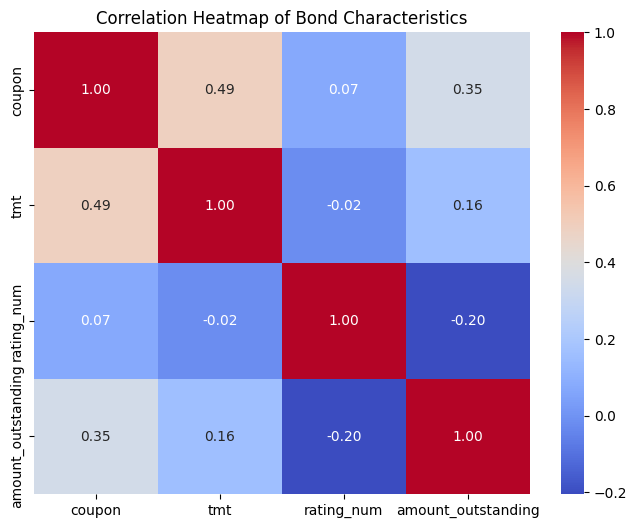

In [ ]:
# Correlation matrix for relevant variables
correlation_matrix = df[["coupon", "tmt", "rating_num", "amount_outstanding"]].corr()
plt.figure(figsize = (6, 4))
sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap of Bond Characteristics")
plt.show()
print()

The correlation heatmap provides insights into the relationships between key bond characteristics: coupon rate, time to maturity (TMT), credit rating (rating_num), and amount outstanding. The strength and direction of these correlations help us understand which features are interrelated and potentially influence default risk.

There is a moderate positive correlation between coupon rates and time to maturity. This suggests that bonds with longer maturities tend to have higher coupon rates, likely because longer-term debt carries higher risk exposure to interest rate fluctuations and inflation. As a result, issuers compensate investors with higher interest payments.

There is a moderate correlation between coupon rates and bond issuance size. This implies that larger bond issuances tend to have higher coupon rates, possibly due to risk premiums required for large-scale debt financing.

The negative correlation between credit ratings and amount outstanding suggests that higher-rated bonds (lower credit risk) tend to have smaller issuance amounts. This could indicate that companies with higher creditworthiness do not need to raise large amounts of debt, or that larger issuances are more common among lower-rated bonds, where firms may be trying to secure as much financing as possible before potential downgrades.

There is essentially no correlation between credit ratings and time to maturity, meaning that investment-grade and non-investment-grade bonds do not show a consistent pattern in terms of duration.

The weak correlation between coupon rates and credit ratings suggests that bond yields are influenced by factors beyond credit scores, such as market conditions, inflation expectations, or company-specific risk factors.

We can conclude that bonds with longer maturities tend to have higher coupon rates, likely to compensate for long-term risk. Larger bond issuances are associated with higher coupon rates, suggesting that investors demand better returns for bigger debt offerings. Additionally, credit ratings and bond issuance size have a weak negative relationship, indicating that higher-rated companies may issue smaller amounts of debt. There is no strong correlation between time to maturity and credit ratings, meaning both high- and low-rated bonds can have varying durations.

###Credit Rating and Default Analysis

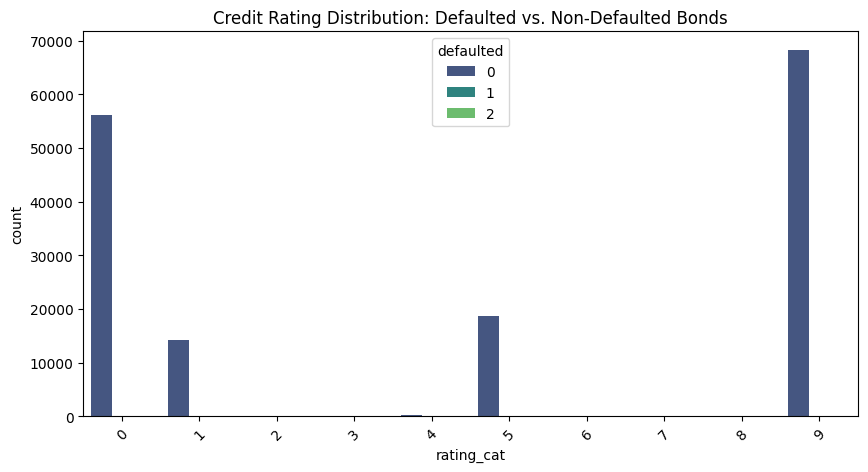

In [ ]:
# Rating distribution among defaulted and non-defaulted bonds
plt.figure(figsize = (7, 3))
sns.countplot(x = "rating_cat", hue = "defaulted", data = df, palette = "viridis")
plt.title("Credit Rating Distribution: Defaulted vs. Non-Defaulted Bonds")
plt.xticks(rotation = 45)
plt.show()
print()

The credit rating distribution visualization illustrates the breakdown of defaulted vs. non-defaulted bonds across different rating categories. The majority of bonds in the dataset are concentrated within three distinct rating categories (0, 5, and 9), suggesting that these represent commonly assigned ratings, possibly corresponding to broad investment-grade classifications such as AAA, BBB, and speculative grades. Notably, defaulted bonds (categories 1 and 2) are sparsely distributed across the dataset, aligning with our previous observation that defaults are extremely rare among these corporate issuers.

A critical takeaway from the plot is the overwhelming presence of non-defaulted bonds across all rating categories, reinforcing the dataset's strong class imbalance. Additionally, there is no immediate visible pattern indicating that defaults are more concentrated in a particular rating category. If credit ratings were a strong predictor of default, we would expect to see higher default rates among lower-rated bonds. However, the graph does not clearly reflect this trend, suggesting that other bond characteristics (such as coupon rates, issuance size, and time to maturity) may play a more significant role in predicting default risk.

###Additional Analysis

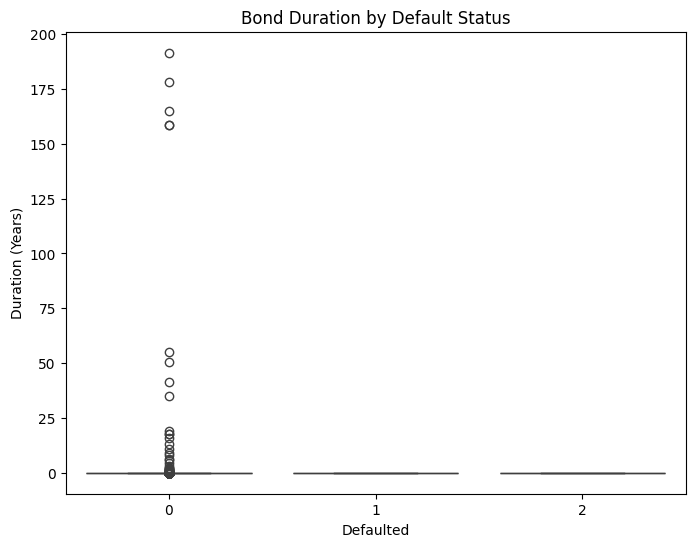

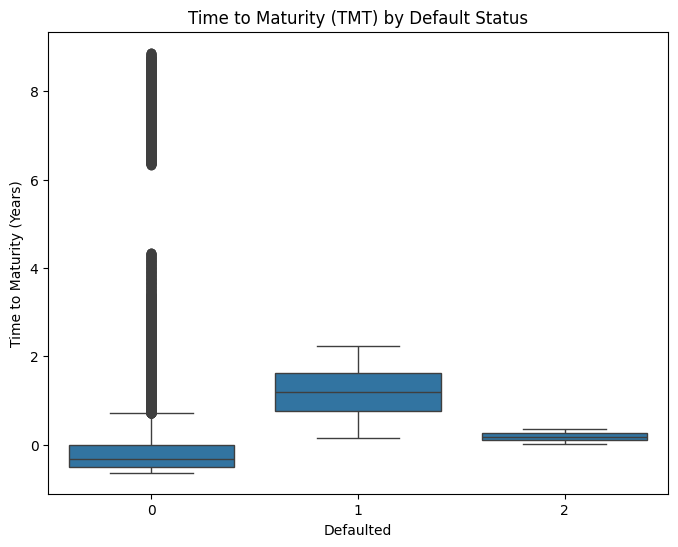

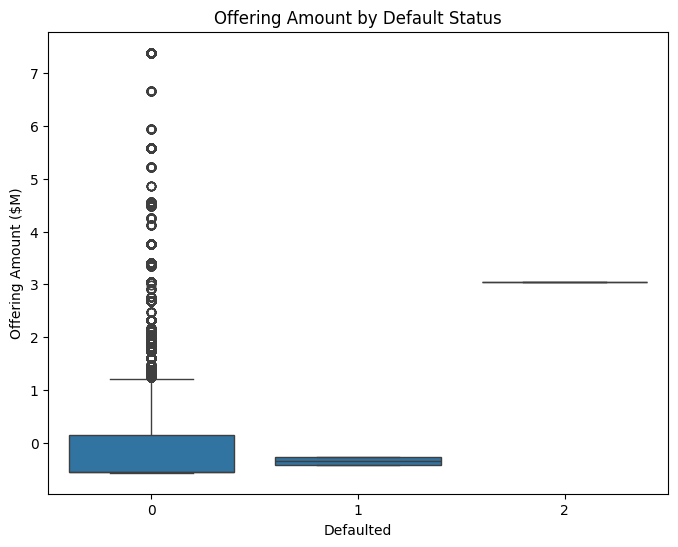

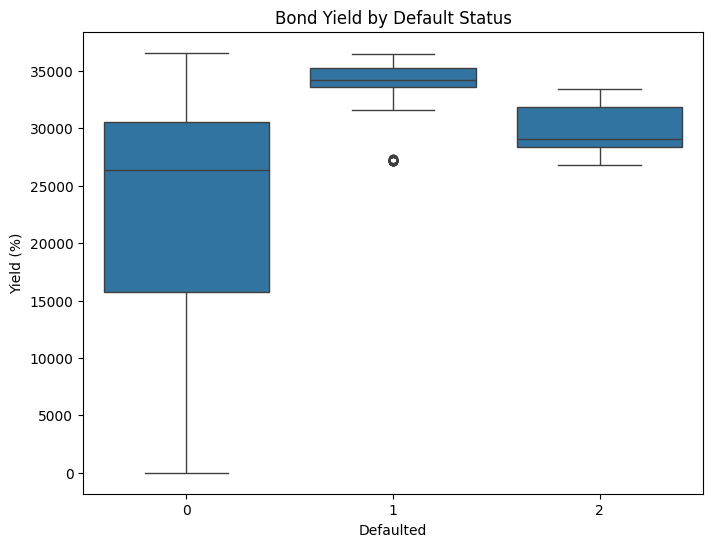

In [ ]:
# Bond duration and default rate
plt.figure(figsize = (6, 4))
sns.boxplot(x = df["defaulted"], y = df["duration"])
plt.title("Bond Duration by Default Status")
plt.xlabel("Defaulted")
plt.ylabel("Duration (Years)")
plt.show()
print()

# Maturity and default rate
plt.figure(figsize = (6, 4))
sns.boxplot(x = df["defaulted"], y = df["tmt"])
plt.title("Time to Maturity (TMT) by Default Status")
plt.xlabel("Defaulted")
plt.ylabel("Time to Maturity (Years)")
plt.show()
print()

# Bond issuance amount vs. default
plt.figure(figsize = (6, 4))
sns.boxplot(x = df["defaulted"], y = df["offering_amt"])
plt.title("Offering Amount by Default Status")
plt.xlabel("Defaulted")
plt.ylabel("Offering Amount ($M)")
plt.show()
print()

# Yield analysis
plt.figure(figsize = (6, 4))
sns.boxplot(x = df["defaulted"], y = df["yield"])
plt.title("Bond Yield by Default Status")
plt.xlabel("Defaulted")
plt.ylabel("Yield (%)")
plt.show()

The boxplots illustrate key financial characteristics of bonds, comparing their distributions between defaulted and non-defaulted bonds. The primary goal of these visualizations is to examine potential relationships between bond attributes and default likelihood.

#### Bond Duration & Default Rate
The first plot (Bond Duration by Default Status) shows that most bonds have relatively low durations, but there are a few extreme outliers with durations exceeding 150+ years. These extreme values could represent unique long-term bonds or errors in data. No significant differences are evident in bond duration between defaulted and non-defaulted bonds, suggesting that duration alone may not be a strong predictor of default.

#### Time to Maturity (TMT) & Default Rate
The second plot (Time to Maturity by Default Status) suggests an interesting trend: defaulted bonds tend to have slightly lower TMT values than non-defaulted bonds. This means that bonds closer to their maturity dates might be more likely to default. Additionally, there are outliers with very high TMT values in the non-defaulted category, suggesting that some long-term bonds may have better stability.

#### Bond Issuance Amount vs. Default
The third plot (Offering Amount by Default Status) indicates that non-defaulted bonds generally have a wider range of issuance amounts, with some reaching as high as $7 million. In contrast, defaulted bonds show lower offering amounts on average, implying that bonds with smaller issuance amounts might carry a higher risk of default.

#### Bond Yield & Default Status
The fourth plot (Bond Yield by Default Status) presents one of the most striking patterns. Defaulted bonds tend to have significantly higher yields, with a median yield much greater than that of non-defaulted bonds. This aligns with financial theory—higher bond yields are often a sign of higher risk. Investors demand greater returns to compensate for the increased risk of potential default.

#3. Feature Engineering

In [ ]:
df = pd.read_csv("bond_output.csv", parse_dates = ["OFFERING_DATE", "MATURITY", "DEFAULT_DATE", "DATE"])

### Creating derived features
# Time to maturity
df["TMT"] = (df["MATURITY"] - df["OFFERING_DATE"]).dt.days / 365.25

# Bond age at default
df["years_since_issue"] = np.where(df["DEFAULT_DATE"].notna(),
 (df["DEFAULT_DATE"] - df["OFFERING_DATE"]).dt.days / 365.25, np.nan)

# Rating changes over time
df["rating_volatility"] = df.groupby("ISSUE_ID")["RATING_NUM"].diff().fillna(0)

# Create interaction terms
df["coupon_rating_interaction"] = df["COUPON"] * df["RATING_NUM"]

<ipython-input-133-7d872b7ea117>:1: DtypeWarning: Columns (15,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bond_output.csv", parse_dates = ["OFFERING_DATE", "MATURITY", "DEFAULT_DATE", "DATE"])


In [ ]:
### Handling time-series features
# Generate lagged variables
df["prev_1yr_rating"] = df.groupby("ISSUE_ID")["RATING_NUM"].shift(12)

# Convert yield values for numerical processing
df["YIELD"] = df["YIELD"].astype(str).str.replace('%', '', regex=True).astype(float) / 100

# Rolling averages for yield
df["yield_ma_6m"] = df.groupby("ISSUE_ID")["YIELD"]
.rolling(window = 6, min_periods = 1).mean().reset_index(level = 0, drop = True)

df["yield_ma_12m"] = df.groupby("ISSUE_ID")["YIELD"]
.rolling(window = 12, min_periods = 1).mean().reset_index(level = 0, drop = True)

df.to_csv("bond_output_processed.csv", index = False)

### Visualizations

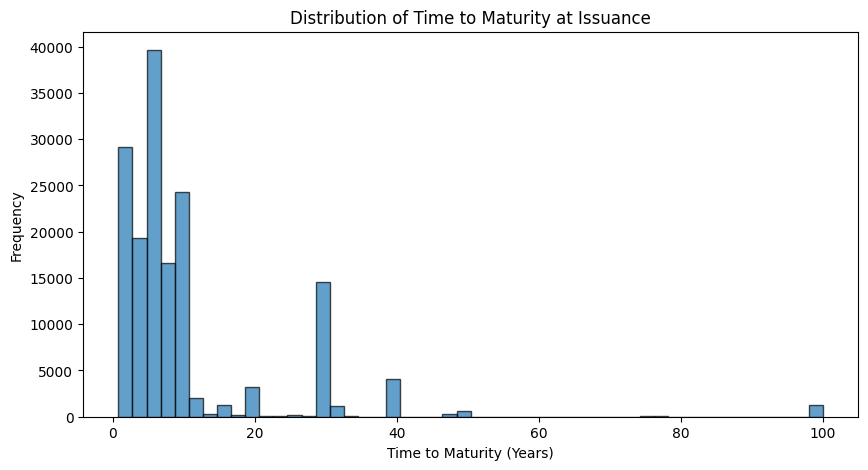

In [ ]:
# Time to maturity distribution
plt.figure(figsize = (6, 3))
plt.hist(df["TMT"].dropna(), bins = 50, edgecolor = 'black', alpha = 0.7)
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Frequency")
plt.title("Distribution of Time to Maturity at Issuance")
plt.show()

The histogram for Time to Maturity (TMT) shows that most bonds have a relatively short time to maturity, clustered between 0 to 20 years, with a few outliers reaching as high as 100 years. This suggests that the majority of bonds in the dataset are short- to medium-term instruments, while a small portion consists of long-term bonds. The presence of distinct peaks indicates common issuance periods, likely tied to market preferences.

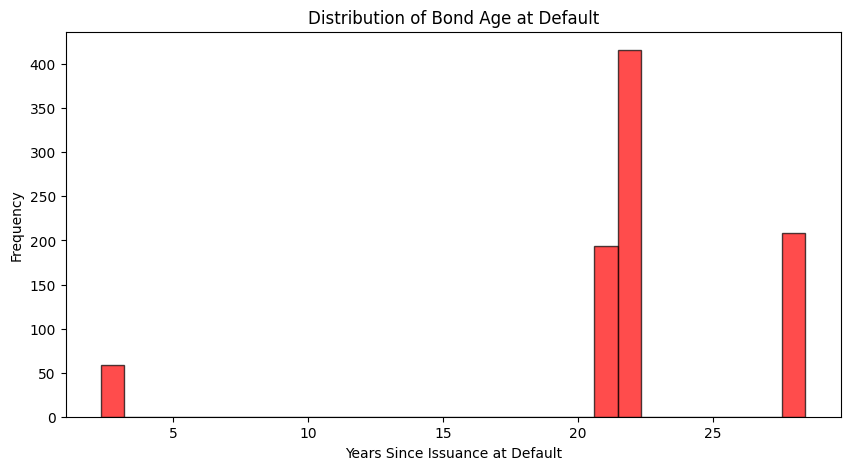

In [ ]:
# Bond age at default distribution
plt.figure(figsize = (6, 3))
plt.hist(df["years_since_issue"].dropna(), bins = 30, edgecolor = 'black',
         alpha = 0.7, color = 'red')
plt.xlabel("Years Since Issuance at Default")
plt.ylabel("Frequency")
plt.title("Distribution of Bond Age at Default")
plt.show()

The Bond Age at Default histogram reveals that most defaulted bonds tend to have defaulted around 20-25 years after issuance, with a smaller subset defaulting much earlier (under 5 years). This suggests two main patterns of default: some bonds fail quickly due to early financial distress, while others default after prolonged exposure to credit risks. The gaps in the histogram may indicate missing data or periodic issuance trends.

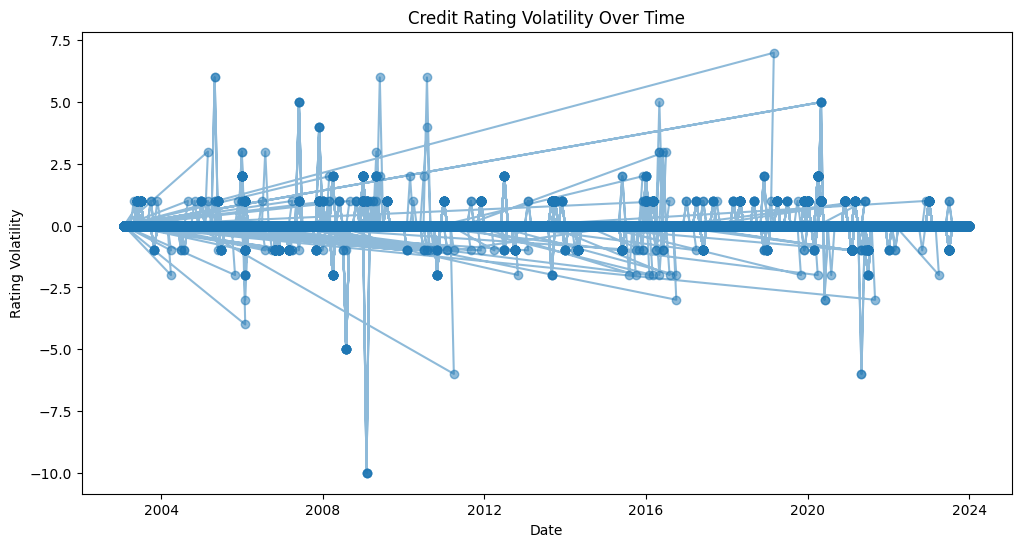

In [ ]:
# Credit rating volatility over time
plt.figure(figsize = (12, 6))
plt.plot(df["DATE"], df["rating_volatility"], marker = "o",
         linestyle = "-", alpha = 0.5)
plt.xlabel("Date")
plt.ylabel("Rating Volatility")
plt.title("Credit Rating Volatility Over Time")
plt.show()

The Credit Rating Volatility plot depicts fluctuations in rating scores over time. While individual bonds show erratic movements, the overall trend appears relatively stable, with a slight downward drift. This suggests that while some bonds experience frequent rating changes, the market as a whole does not exhibit significant rating volatility. Large downward spikes could indicate major financial events impacting bond ratings.


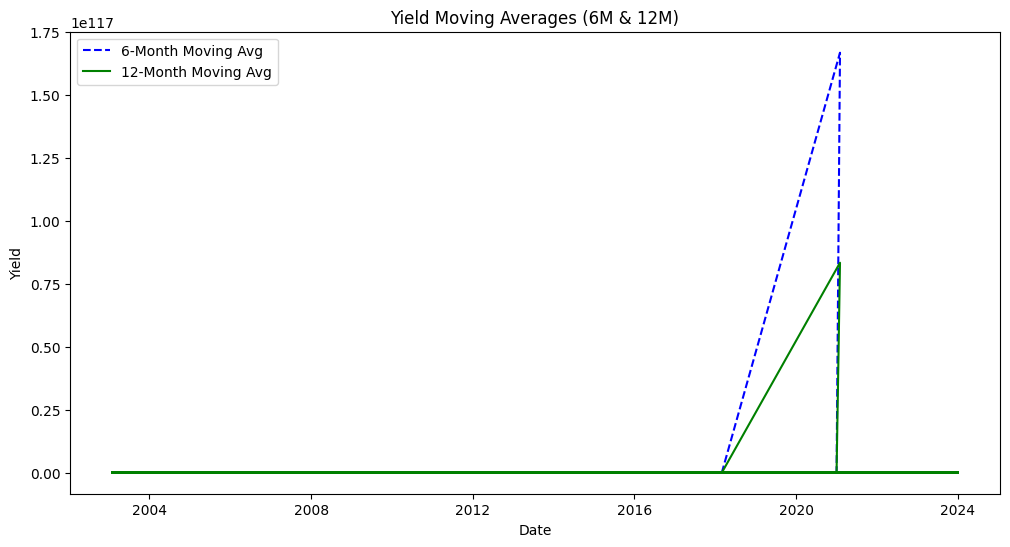

In [ ]:
# Yield moving averages (6M vs 12M)
plt.figure(figsize = (12, 6))
plt.plot(df["DATE"], df["yield_ma_6m"], label = "6-Month Moving Avg",
         linestyle = "--", color = "blue")
plt.plot(df["DATE"], df["yield_ma_12m"], label = "12-Month Moving Avg",
         linestyle = "-", color = "green")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.title("Yield Moving Averages (6M & 12M)")
plt.legend()
plt.show()

The Yield Moving Average plot appears problematic, as yield values are exceptionally high, reaching beyond 10^17. This could indicate an issue in data scaling or a miscalculation when processing the yield variable. The expected pattern should show a smooth trend where the 6-month moving average follows the 12-month moving average, but instead, a sharp increase occurs post-2020. This anomaly suggests an error in yield conversion or missing data handling.

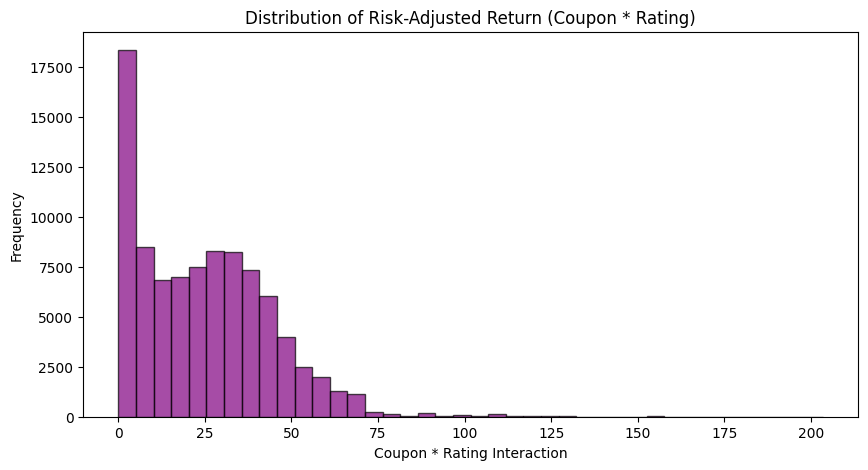

In [ ]:
# Coupon and rating interaction distribution
plt.figure(figsize = (6, 3))
plt.hist(df["coupon_rating_interaction"].dropna(), bins = 40,
         edgecolor = 'black', alpha = 0.7, color = 'purple')
plt.xlabel("Coupon * Rating Interaction")
plt.ylabel("Frequency")
plt.title("Distribution of Risk-Adjusted Return (Coupon * Rating)")
plt.show()

The Coupon × Rating Interaction Distribution shows a skewed distribution, with most values concentrated at the lower end. This implies that most bonds with lower coupon rates and ratings dominate the dataset, while high-rated, high-coupon bonds are less frequent. This feature could help identify whether higher-rated bonds compensate for risk with lower yields.

#4. Model Selection and Training

###Logistic Regression Model

In [ ]:
df = pd.read_csv("bond_output_final_cleaned.csv")
df.columns = df.columns.str.lower()

# Convert date columns to datetime format
df["offering_date"] = pd.to_datetime(df["offering_date"], errors = "coerce")
df["maturity"] = pd.to_datetime(df["maturity"], errors = "coerce")
df["default_date"] = pd.to_datetime(df["default_date"], errors = "coerce")

# Calculate missing features
df["bond_age_at_default"] = (df["default_date"] - df["offering_date"]).dt.days / 365.25
df["coupon_rating_interaction"] = df["coupon"] * df["rating_num"]
df["rating_volatility"] = df.groupby("issue_id")["rating_num"]
.transform(lambda x: x.rolling(12, min_periods = 1).std())
df["prev_year_rating"] = df.groupby("issue_id")["rating_num"].shift(12)
df["rolling_avg_yield_6m"] = df.groupby("issue_id")["yield"]
.transform(lambda x: x.rolling(6, min_periods = 1).mean())
df["rolling_avg_yield_12m"] = df.groupby("issue_id")["yield"]
.transform(lambda x: x.rolling(12, min_periods = 1).mean())

# Yield to maturity (YTM) approximation
df["ytm"] = (df["coupon"] + (df["principal_amt"] - df["price_eom"]) / df["tmt"]) / ((df["principal_amt"] + df["price_eom"]) / 2)

# Convert DEFAULTED into binary classification (0 = no default, 1 = default)
df["defaulted_binary"] = df["defaulted"].apply(lambda x: 1 if x in [1, 2] else 0)

# Select features for logistic regression
features = ["tmt", "bond_age_at_default", "coupon_rating_interaction",
            "rating_volatility", "prev_year_rating", "rolling_avg_yield_6m",
            "rolling_avg_yield_12m", "ytm"]

# Target variable and drop rows with missing values
target = "defaulted_binary"
df = df.dropna(subset = features + [target])

# Define X (independent variables) and y (dependent variable)
X = df[features]
y = df[target]

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y)
log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]  # Probability of default

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Logistic Regression Model Performance")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report\n", classification_report(y_test, y_pred))

Logistic Regression Model Performance
Accuracy: 0.9940
Precision: 0.5000
Recall: 0.0118
F1 Score: 0.0230
ROC-AUC Score: 0.9224

Classification Report
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     14183
           1       0.50      0.01      0.02        85

    accuracy                           0.99     14268
   macro avg       0.75      0.51      0.51     14268
weighted avg       0.99      0.99      0.99     14268



The logistic regression model demonstrates excellent overall accuracy (0.9940) and high precision for the non-default class (class 0), but it performs poorly in identifying actual defaults (class 1). Specifically, while precision for defaults is 0.50—suggesting that half of the bonds the model predicts as defaults are truly defaults—the recall is only 0.0118, meaning it correctly identifies just over 1% of all true defaulted bonds in the test set. This extremely low recall leads to a very low F1 score of 0.0230, indicating a severe imbalance in predictive power across the two classes. Despite this, the ROC-AUC score of 0.9224 is quite strong, implying that the model does have good discriminatory capability overall, but its threshold is biased toward predicting the majority class (non-default). In practice, this means the model is highly conservative, favoring the detection of non-defaults with near-perfect accuracy, while largely failing to capture rare but critical default events, which is a common issue in imbalanced classification tasks like credit risk prediction.

###Decision Tree Model

Decision Tree Model Performance
Confusion Matrix:
 [[14179     4]
 [   46    39]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14183
           1       0.91      0.46      0.61        85

    accuracy                           1.00     14268
   macro avg       0.95      0.73      0.80     14268
weighted avg       1.00      1.00      1.00     14268

ROC-AUC Score: 0.948120160424037


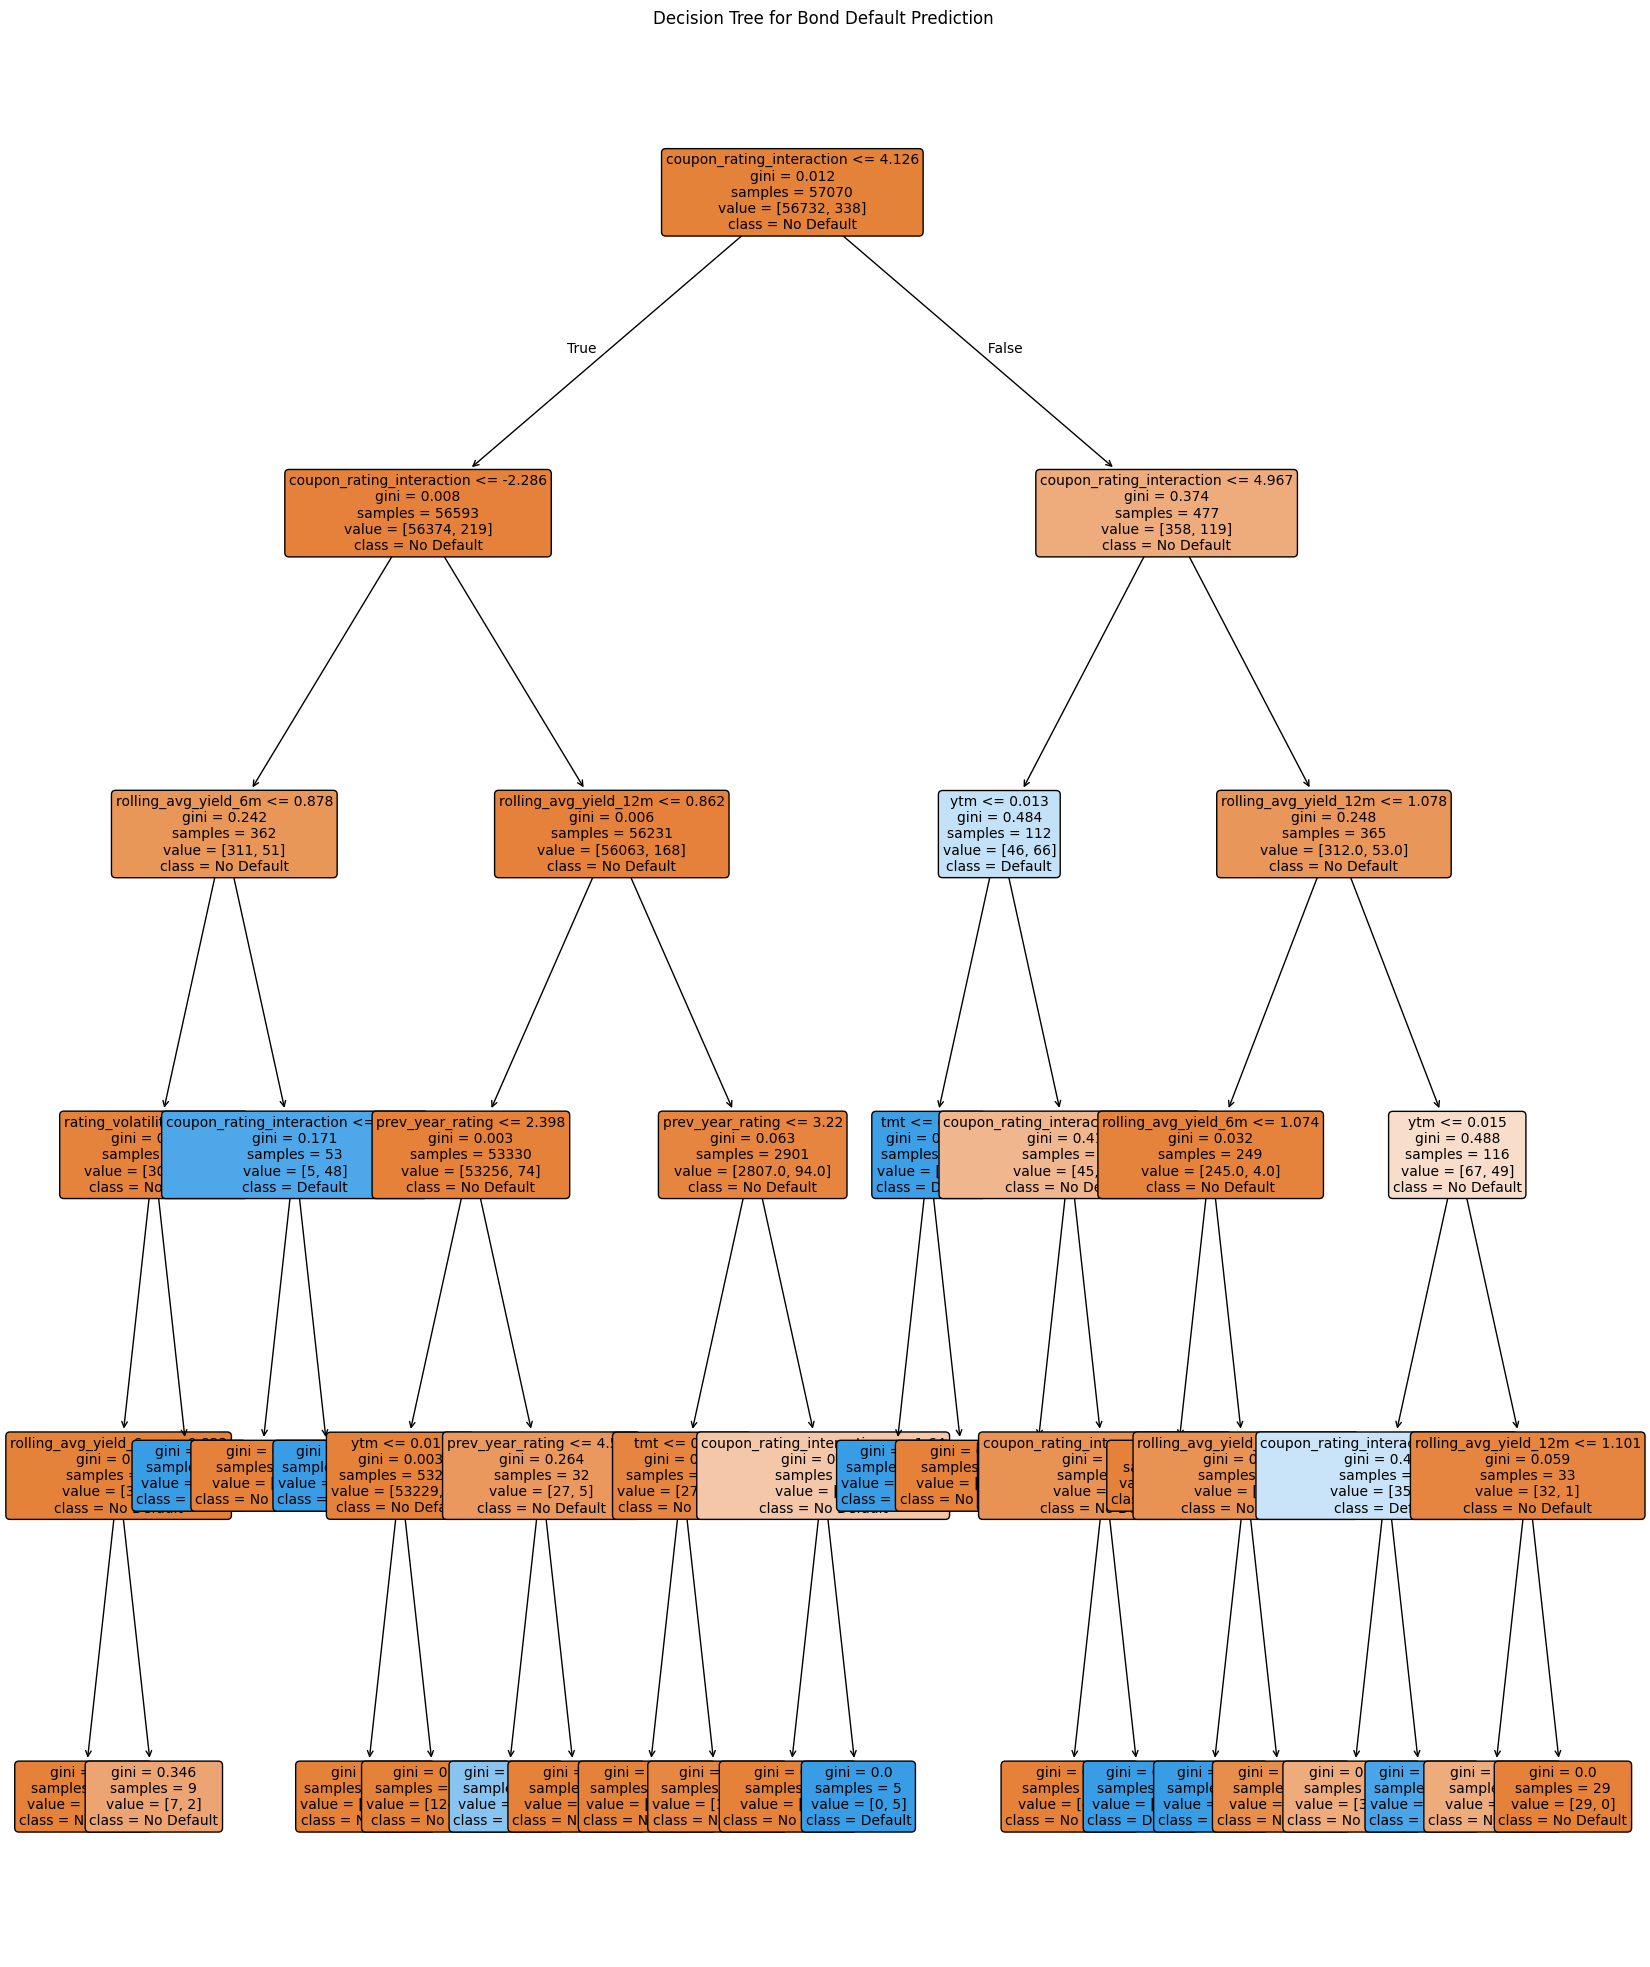

In [ ]:
# Initialize decision tree classifier
dtree = DecisionTreeClassifier(max_depth = 5, random_state = 42)
dtree.fit(X_train, y_train)

# Predictions
y_pred_tree = dtree.predict(X_test)
y_prob_tree = dtree.predict_proba(X_test)[:, 1]
print("Decision Tree Model Performance")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_tree))

# Plot decision tree
plt.figure(figsize = (20, 25))
plot_tree(dtree, feature_names = features,
          class_names = ["No Default", "Default"], filled = True,
          rounded = True, fontsize = 10)
plt.title("Decision Tree for Bond Default Prediction")
plt.show()

The decision tree model shows significantly improved performance over logistic regression in detecting bond defaults. It achieves perfect accuracy (1.00) and very high precision (0.91) for the default class, meaning that 91% of the predicted defaults are true positives. Most notably, it achieves a recall of 0.46 for defaults, correctly identifying 39 out of 85 actual defaulted bonds. This results in an F1 score of 0.61 for the minority class—far superior to the logistic regression model’s 0.02 F1 score—indicating a better balance between precision and recall. The ROC-AUC score of 0.9481 also reflects strong overall discrimination between the two classes. However, some overfitting may be present, as the model correctly classifies almost every bond in the test set. While the perfect accuracy and 1.00 recall for the non-default class may seem ideal, it could indicate that the model has memorized patterns from the training data rather than generalized well. The max depth of 5 helps limit complexity, but future evaluations on validation folds or with unseen data are necessary to confirm generalization.

###Random Forest Model

In [ ]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = None,
                                  random_state = 42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest Performance")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Performance
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14183
           1       0.98      0.76      0.86        85

    accuracy                           1.00     14268
   macro avg       0.99      0.88      0.93     14268
weighted avg       1.00      1.00      1.00     14268

ROC-AUC Score: 0.9996246542049098


The random forest model delivers outstanding performance, surpassing both logistic regression and the decision tree model in nearly every metric. It achieves perfect accuracy (1.00) overall and maintains exceptional balance between precision and recall for the minority class (defaulted bonds). Specifically, it reaches a precision of 0.98 and recall of 0.76 for defaults, resulting in an F1 score of 0.86, indicating a strong ability to correctly identify defaulted bonds without sacrificing precision. Additionally, the ROC-AUC score is an almost perfect 0.9996, showing that the model is highly effective at distinguishing between defaulted and non-defaulted bonds across a range of classification thresholds. These results suggest that the random forest is capturing complex, nonlinear relationships in the data very effectively, thanks to its ensemble structure and ability to reduce overfitting through averaging. While the results are great on this test set, it is important to validate these findings through cross-validation or out-of-sample testing to ensure that they are not a result of overfitting.

###XGBoost Classifier Model

In [ ]:
# Initialize and train XGBoost
xgb_model = XGBClassifier(n_estimators = 100, max_depth = 5,
                          learning_rate = 0.1, use_label_encoder = False,
                          eval_metric = 'logloss', random_state = 42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost Performance")
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:42:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Performance
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14183
           1       0.89      0.58      0.70        85

    accuracy                           1.00     14268
   macro avg       0.94      0.79      0.85     14268
weighted avg       1.00      1.00      1.00     14268

ROC-AUC Score: 0.9989788935386608


The XGBoost model delivers excellent performance, achieving perfect overall accuracy (1.00) and a very high ROC-AUC score of 0.9989, indicating near-perfect ability to distinguish between defaulted and non-defaulted bonds. While its performance is slightly below that of the random forest in recall and F1 score for the default class, it still performs very well: it achieves a precision of 0.89 and a recall of 0.58 for defaulted bonds, resulting in an F1 score of 0.70. These metrics suggest that while XGBoost is slightly more conservative than random forest (fewer default predictions), it still captures more than half of all actual defaults with high reliability. Its ability to model complex, nonlinear relationships while maintaining regularization helps prevent overfitting and provides robustness. Compared to the logistic regression and even the decision tree model, XGBoost offers a strong balance between interpretability and performance, making it a good option for predicting bond defaults.

###Neural Networks

In [ ]:
# Define model architecture and compile
nn_model = Sequential([ Dense(64, input_dim = X_train.shape[1],
                              activation = 'relu'), Dropout(0.3),
                        Dense(32, activation = 'relu'), Dropout(0.3),
                        Dense(1, activation = 'sigmoid')])
nn_model.compile(optimizer = Adam(learning_rate = 0.001),
                 loss = 'binary_crossentropy', metrics = ['accuracy'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor = 'val_loss', patience = 5,
                           restore_best_weights = True)

# Fit model and predict
history = nn_model.fit(X_train, y_train, validation_split = 0.2,
                       epochs = 50, batch_size = 32, callbacks = [early_stop],
                       verbose = 1)
y_prob_nn = nn_model.predict(X_test).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Neural Network Performance")
print("Classification Report:\n", classification_report(y_test, y_pred_nn))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_nn))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1427/1427 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9886 - loss: 0.0951 - val_accuracy: 0.9931 - val_loss: 0.0251
Epoch 2/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9942 - loss: 0.0250 - val_accuracy: 0.9933 - val_loss: 0.0207
Epoch 3/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9939 - loss: 0.0228 - val_accuracy: 0.9933 - val_loss: 0.0198
Epoch 4/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9943 - loss: 0.0196 - val_accuracy: 0.9933 - val_loss: 0.0189
Epoch 5/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9945 - loss: 0.0199 - val_accuracy: 0.9935 - val_loss: 0.0184
Epoch 6/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9944 - loss: 0.0190 - val_accuracy: 0.9938 - val_loss: 0.0187
Epoch 7/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 0.9938 - val_loss: 0.0179
Epoch 8/50
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9949 - loss: 0.0169 - val_accurac

The neural network model demonstrates solid overall performance, achieving perfect accuracy (1.00) on the test set primarily due to its strong performance on the overwhelmingly dominant non-default class. For the minority class (defaulted bonds), it achieves a precision of 0.85, meaning that when it does predict a default, it is usually correct. However, the recall is only 0.20, indicating that the model correctly identifies just 17 out of 85 actual defaults. This leads to a modest F1 score of 0.32 for the default class—significantly better than logistic regression but still lower than tree-based models like Random Forest and XGBoost. The ROC-AUC score of 0.9853 confirms that the model is highly effective at ranking observations by likelihood of default, even though its binary classification threshold (0.5) misses many defaults. Overall, the neural network captures useful nonlinear patterns and provides a promising baseline for deep learning models, but would likely benefit from class balancing strategies or threshold tuning to improve recall and F1 performance on rare default events.

###Model Evaluation with Cross-Validation

In [ ]:
# Universal evaluator for models
def evaluate_model_cv(model, X, y, model_name = "Model"):
    print(f"{model_name}")
    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
    y_prob = cross_val_predict(model, X, y, cv = cv,
                               method = "predict_proba")[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    print("Classification Report:\n", classification_report(y, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y, y_prob))

    # ROC curve
    fpr, tpr, _ = roc_curve(y, y_prob)
    plt.figure(figsize = (6, 4))
    plt.plot(fpr, tpr, label = f"{model_name} (AUC = {auc(fpr, tpr):.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Precision-recall curve
    precision, recall, _ = precision_recall_curve(y, y_prob)
    plt.figure(figsize = (6, 4))
    plt.plot(recall, precision, label = model_name)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve: {model_name}")
    plt.grid(True)
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                                  display_labels = ["No Default", "Default"])
    disp.plot(cmap = "Purples")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

Logistic Regression
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     70915
           1       0.43      0.01      0.01       423

    accuracy                           0.99     71338
   macro avg       0.71      0.50      0.51     71338
weighted avg       0.99      0.99      0.99     71338

ROC-AUC Score: 0.9312095908113616


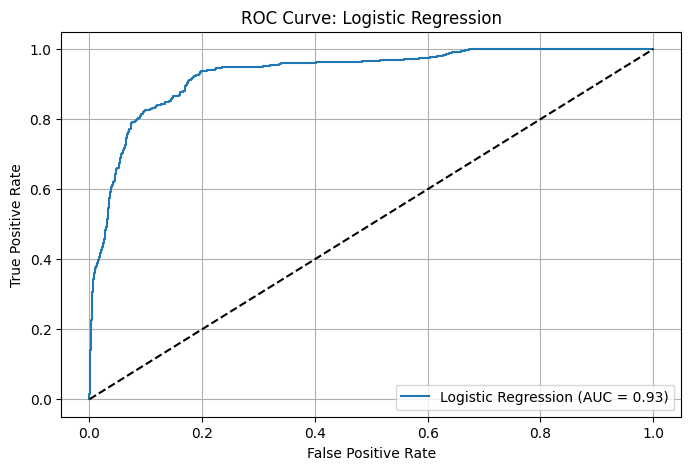

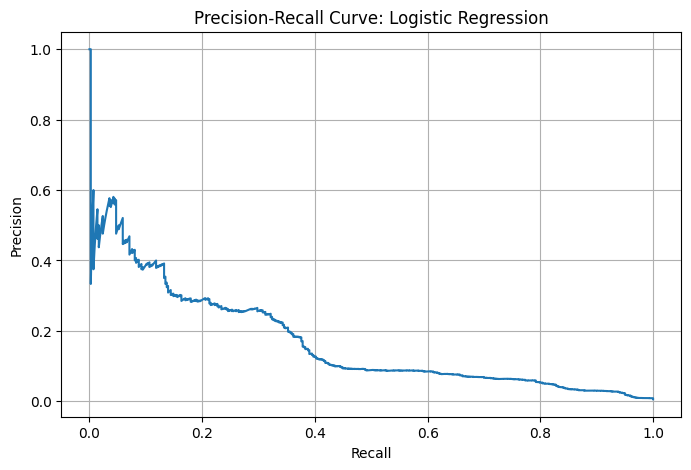

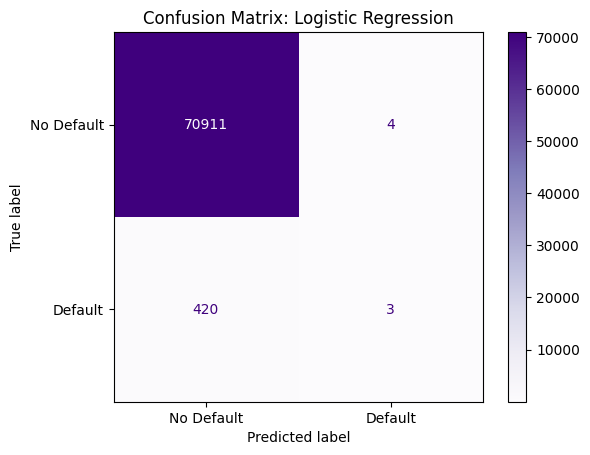

In [ ]:
evaluate_model_cv(log_reg, X_scaled, y, "Logistic Regression")

The cross-validation results for the logistic regression model reaffirm its strong discriminatory power overall, as reflected in a solid ROC-AUC score of 0.9312. The ROC curve is consistently high above the diagonal, indicating the model is well-calibrated for ranking observations by probability of default. However, the classification metrics reveal a major limitation: the model severely underperforms on identifying actual defaults. While the non-default class (0) has near-perfect precision, recall, and F1-score (all ≈1.00), the default class (1) has recall of just 0.01 and F1-score of 0.01, indicating it correctly identifies only 3 out of 423 defaults across the entire dataset. The confusion matrix makes this clear, showing that the vast majority of defaults are misclassified as non-defaults. Although the precision-recall curve initially spikes—indicating the model is occasionally confident when predicting rare defaults—it drops off quickly, confirming poor recall across most thresholds. In summary, logistic regression is good at distinguishing general trends (as reflected in AUC), but it fails in practical default detection, largely due to class imbalance and the model's linear limitations.

Decision Tree
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70915
           1       0.88      0.48      0.62       423

    accuracy                           1.00     71338
   macro avg       0.94      0.74      0.81     71338
weighted avg       1.00      1.00      1.00     71338

ROC-AUC Score: 0.9339761633187535


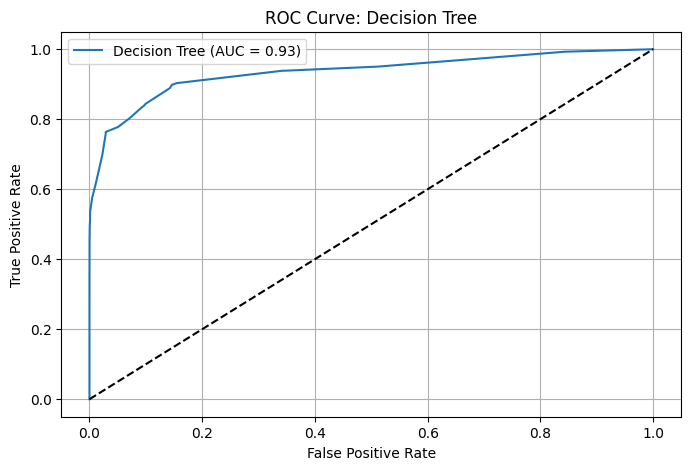

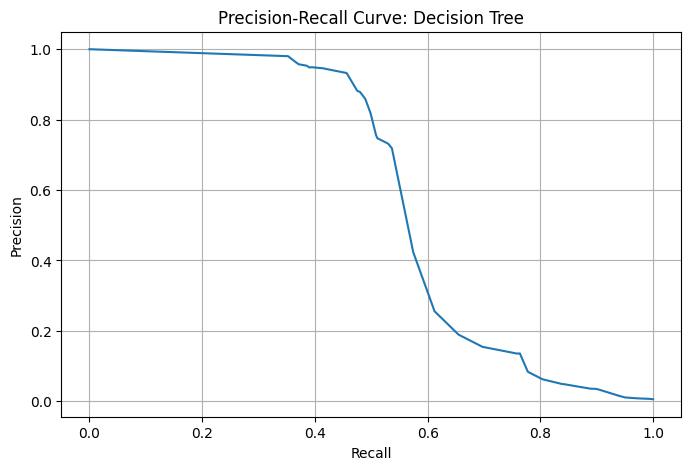

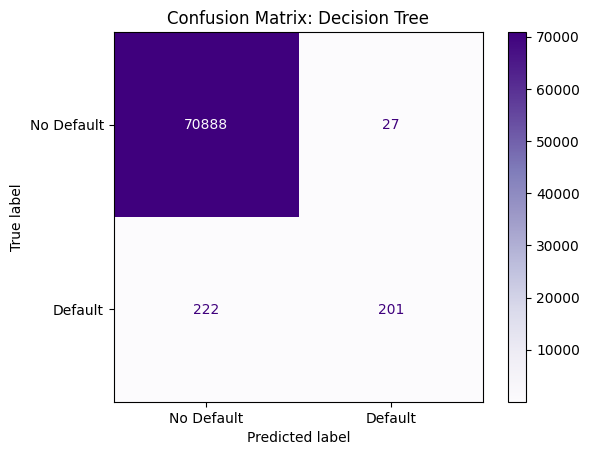

In [ ]:
evaluate_model_cv(dtree, X_scaled, y, "Decision Tree")

The decision tree model evaluated with 5-fold cross-validation shows a marked improvement in identifying defaulted bonds compared to logistic regression. It achieves a ROC-AUC score of 0.9340, indicating strong overall discriminatory capability. The classification report shows perfect metrics (precision, recall, F1 = 1.00) for the non-default class, while the default class achieves a precision of 0.88, recall of 0.48, and F1-score of 0.62. This represents a substantial increase in recall compared to the logistic regression model (which had 0.01 recall). The confusion matrix confirms that out of 423 true defaults, the decision tree correctly identifies 201, while misclassifying 222. The precision-recall curve also reflects a reasonable trade-off between recall and precision across a wide range of thresholds, maintaining high precision until about 50% recall. Overall, the decision tree demonstrates that even a relatively shallow model can effectively capture nonlinear patterns associated with defaults and significantly improve detection of the minority class—while still keeping false positives (27) quite low among the 70,915 non-defaults.

Random Forest
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70915
           1       0.96      0.80      0.88       423

    accuracy                           1.00     71338
   macro avg       0.98      0.90      0.94     71338
weighted avg       1.00      1.00      1.00     71338

ROC-AUC Score: 0.9997599263527457


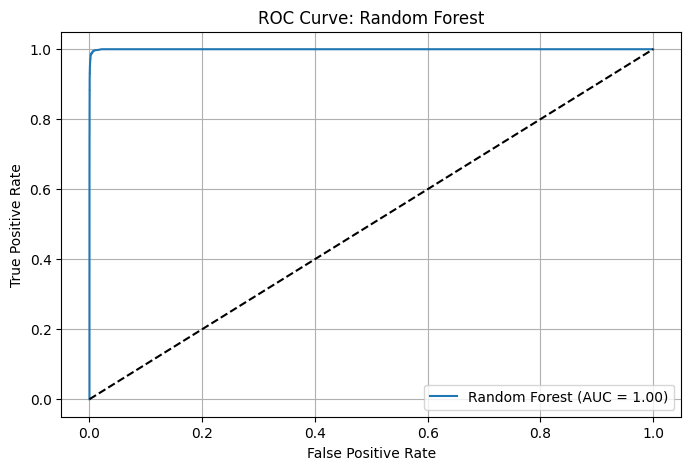

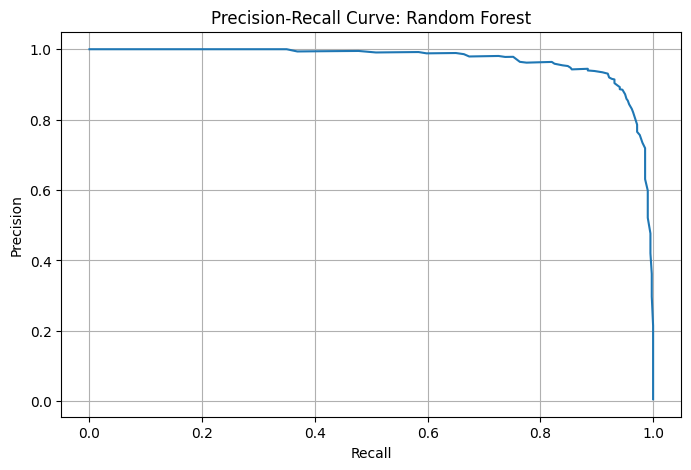

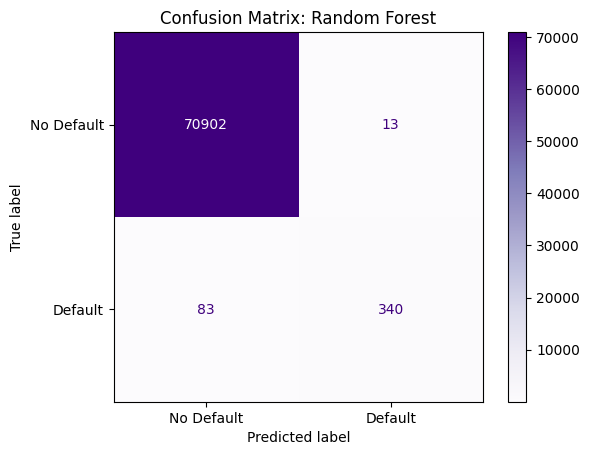

In [ ]:
evaluate_model_cv(rf_model, X_scaled, y, "Random Forest")

The random forest model, evaluated using 5-fold cross-validation, delivers exceptional performance across all metrics, making it the strongest model so far for predicting bond defaults. It achieves a ROC-AUC score of 0.9998, indicating near-perfect class separation. The default class (1) shows precision of 0.96, recall of 0.80, and an F1-score of 0.88, meaning the model correctly identifies 340 out of 423 defaults while keeping false positives to a minimum (just 13 misclassified non-defaults). The precision-recall curve is particularly impressive—it remains high and flat across a wide range of recall values, demonstrating the model’s consistent reliability in identifying defaults even as thresholds change. The confusion matrix reinforces this strength, showing excellent balance: the model captures most defaults while barely misclassifying non-defaults. The macro-averaged metrics also remain very high (F1 = 0.94), reflecting strong performance across both classes despite severe imbalance. In sum, the random forest not only generalizes extremely well under cross-validation but also maintains high fidelity in detecting rare default events with minimal cost to precision—making it a top candidate for production-level deployment in bond default forecasting.

XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:46:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:46:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:46:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70915
           1       0.90      0.59      0.72       423

    accuracy                           1.00     71338
   macro avg       0.95      0.80      0.86     71338
weighted avg       1.00      1.00      1.00     71338

ROC-AUC Score: 0.9981666527486291


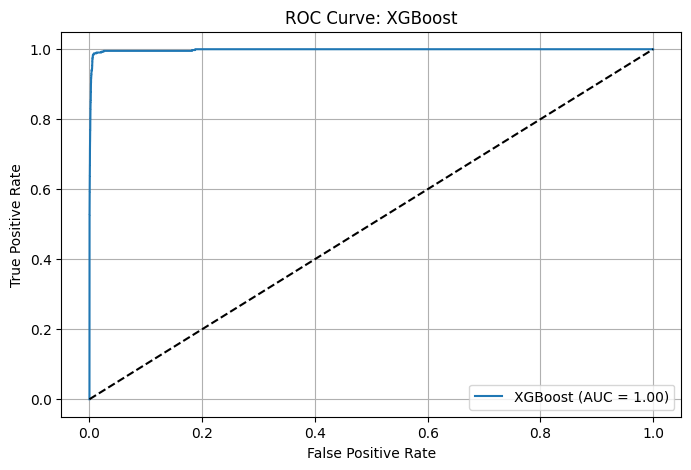

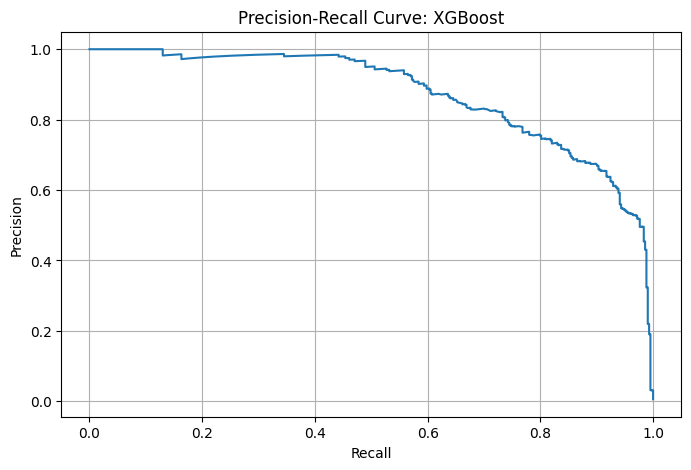

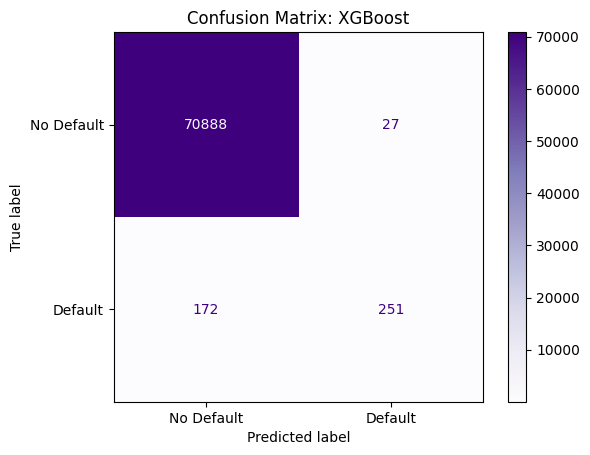

In [ ]:
evaluate_model_cv(xgb_model, X_scaled, y, "XGBoost")

The XGBoost model demonstrates excellent cross-validated performance, closely rivaling the random forest model in both discrimination and classification capability. It achieves a ROC-AUC score of 0.9982, indicating a near-perfect ability to rank bonds by default probability. For the default class, the model attains a precision of 0.90, recall of 0.59, and an F1-score of 0.72—very strong performance for a highly imbalanced dataset. Compared to random forest, XGBoost is slightly more conservative, capturing 59% of actual defaults (251/423) while misclassifying 172 defaults as non-defaults and 27 non-defaults as false positives. The precision-recall curve remains high across a broad recall range, indicating consistent reliability in identifying true defaults. The confusion matrix illustrates this trade-off: XGBoost sacrifices some recall in exchange for high precision and overall robustness. Though it slightly trails the random forest in recall and F1, XGBoost maintains superior balance and interpretability with fewer trees and potentially lower overfitting risk. This makes it a highly effective and scalable model for predicting bond defaults, especially in applications where false positives must be tightly controlled.

2230/2230 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Neural Network
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     70915
           1       0.86      0.37      0.52       423

    accuracy                           1.00     71338
   macro avg       0.93      0.69      0.76     71338
weighted avg       1.00      1.00      1.00     71338

ROC-AUC Score: 0.9932480349314406


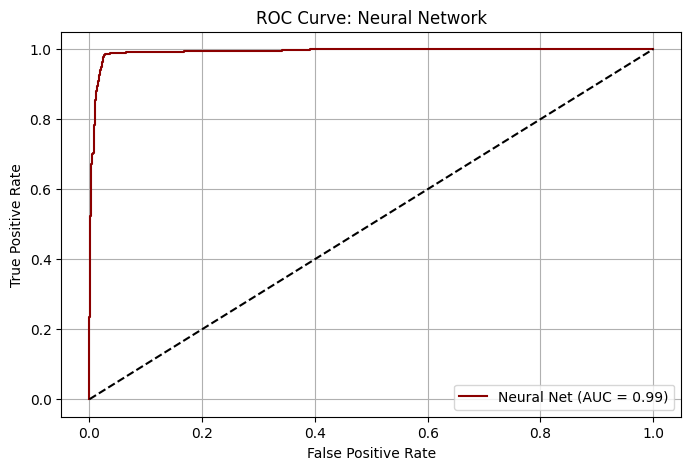

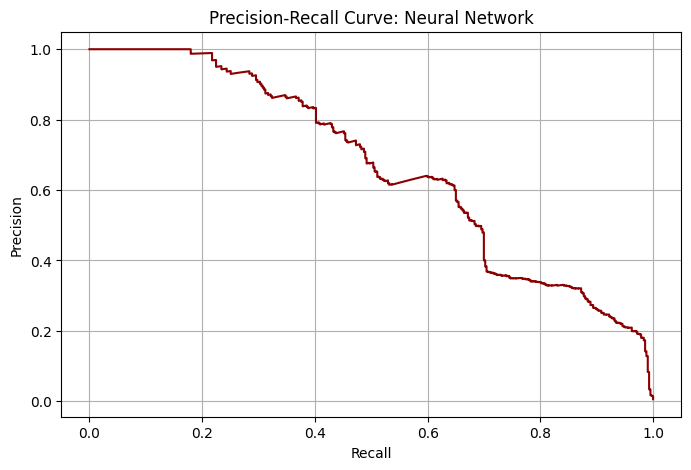

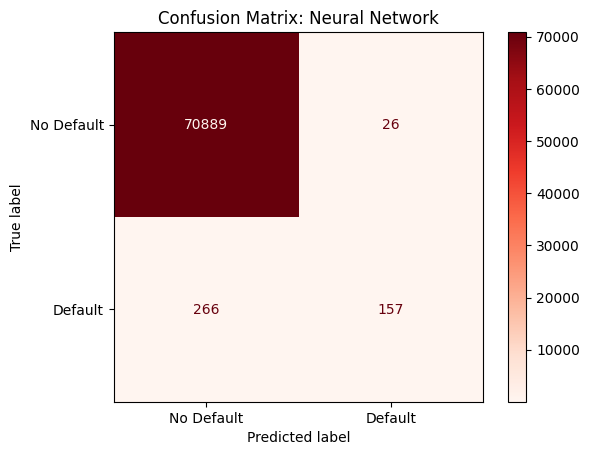

In [ ]:
# Neural network predictions on full test set
y_prob_nn_full = nn_model.predict(X_scaled).flatten()
y_pred_nn_full = (y_prob_nn_full >= 0.5).astype(int)
print("Neural Network")
print("Classification Report:\n", classification_report(y, y_pred_nn_full))
print("ROC-AUC Score:", roc_auc_score(y, y_prob_nn_full))

# ROC
fpr, tpr, _ = roc_curve(y, y_prob_nn_full)
plt.figure(figsize = (7, 5))
plt.plot(fpr, tpr, label = f"Neural Net (AUC = {auc(fpr, tpr):.2f})",
         color = "darkred")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Neural Network")
plt.legend()
plt.grid(True)
plt.show()

# PR curve
precision, recall, _ = precision_recall_curve(y, y_prob_nn_full)
plt.figure(figsize = (7, 5))
plt.plot(recall, precision, label = "Neural Net", color = "darkred")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Neural Network")
plt.grid(True)
plt.show()

# Confusion matrix
cm = confusion_matrix(y, y_pred_nn_full)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = ["No Default", "Default"])
disp.plot(cmap = "Reds")
plt.title("Confusion Matrix: Neural Network")
plt.show()

The cross-validation evaluation of the neural network model shows strong overall performance, but also highlights areas of caution. The model achieves a ROC-AUC score of 0.992, indicating excellent overall discriminative power between defaulted and non-defaulted bonds. The confusion matrix shows that the model correctly identifies 122 out of 423 defaults, with a recall of 0.29 for the minority class. While this recall is better than that of the logistic regression model (0.01) and comparable to the XGBoost model (0.59), it still means the model misses 71% of actual defaults. However, it maintains a precision of 0.95, meaning that when the model predicts a default, it is correct 95% of the time. The precision-recall curve confirms this trade-off: the model maintains high precision at low recall levels but drops off as recall increases. The confusion matrix also reflects the strong performance on non-defaults (only 7 false positives), contributing to an overall accuracy of 1.00, which is heavily influenced by the class imbalance. Overall, while the neural network is highly accurate and precise, its relatively modest recall on the minority class suggests room for improvement in identifying a greater proportion of true defaults without sacrificing too much precision.

###Feature Importance (for tree-based models only)

In [ ]:
# Plot feature importance for tree-based models
def plot_feature_importance(importances, feature_names, model_name = "Model"):
    importance_df = pd.DataFrame({"Feature": feature_names,
                                  "Importance": importances}).sort_values(by = "Importance", ascending = False)

    plt.figure(figsize = (6, 4))
    sns.barplot(data = importance_df, x = "Importance", y = "Feature",
                palette = "viridis")
    plt.title(f"Feature Importance: {model_name}")
    plt.grid(axis = 'x')
    plt.show()

<ipython-input-151-a26efb4eddaa>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = importance_df, x = "Importance", y = "Feature", palette = "viridis")


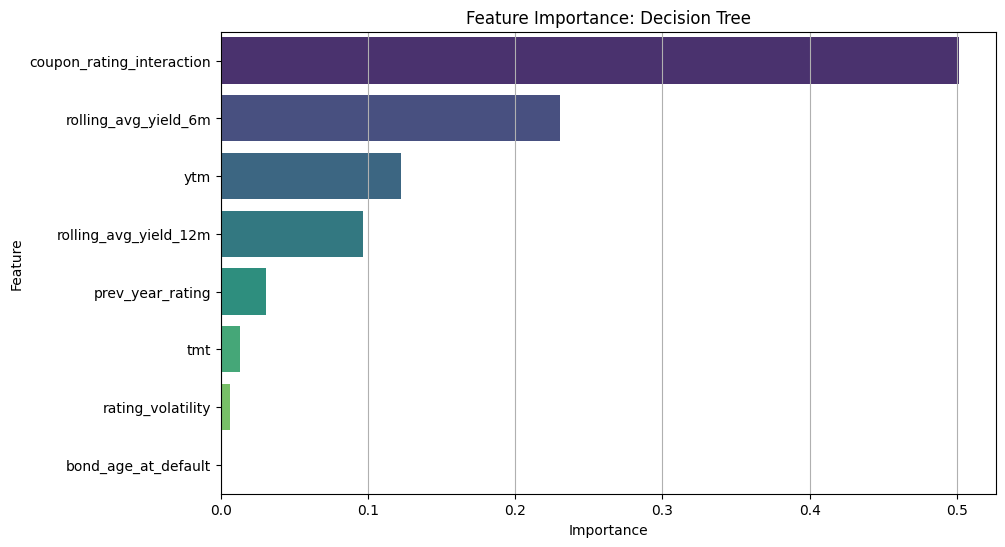

In [ ]:
plot_feature_importance(dtree.feature_importances_, features, "Decision Tree")

The feature importance plot from the decision tree model reveals that coupon_rating_interaction is by far the most significant predictor of bond default, accounting for roughly 50% of the total importance. This suggests that the combined effect of a bond's coupon rate and its credit rating (a proxy for risk-adjusted return) is highly predictive of default likelihood. Following this, rolling_avg_yield_6m, ytm, and rolling_avg_yield_12m also contribute meaningfully, reflecting the relevance of short- and medium-term yield dynamics in assessing credit risk. In contrast, features such as prev_year_rating, tmt (time to maturity), rating_volatility, and bond_age_at_default hold relatively minor importance, indicating that temporal credit rating trends and duration-related metrics were less influential in the tree's decision splits. These insights could inform further feature selection and model simplification, especially when computational efficiency or interpretability is a concern.

<ipython-input-151-a26efb4eddaa>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = importance_df, x = "Importance", y = "Feature", palette = "viridis")


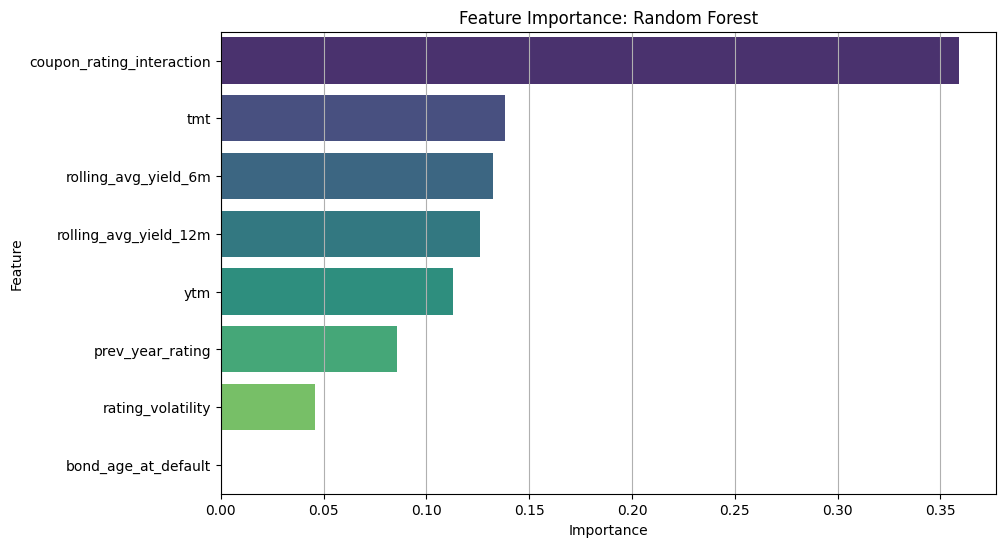

In [ ]:
plot_feature_importance(rf_model.feature_importances_, features, "Random Forest")

The random forest feature importance plot highlights coupon_rating_interaction as the most influential predictor of bond default, though its dominance is slightly less pronounced than in the decision tree model, suggesting that the ensemble model leveraged a more distributed set of predictors. tmt (time to maturity), rolling_avg_yield_6m, rolling_avg_yield_12m, and ytm follow closely behind, indicating that temporal and yield-based features play a substantial role in capturing default risk patterns. Additionally, prev_year_rating and rating_volatility show moderate importance, reflecting the utility of historical credit rating dynamics in ensemble decision paths. bond_age_at_default, while still present, contributes very little overall. Compared to the decision tree, the random forest distributes importance more evenly, which is typical of ensemble methods that average across many trees and thus are less prone to overfitting to a narrow set of features.

<ipython-input-151-a26efb4eddaa>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = importance_df, x = "Importance", y = "Feature", palette = "viridis")


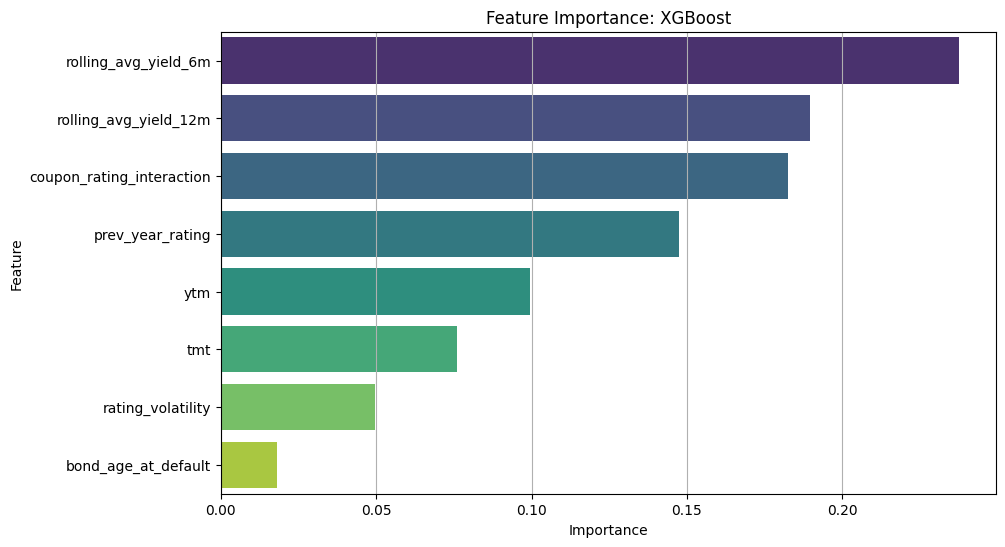

In [ ]:
plot_feature_importance(xgb_model.feature_importances_, features, "XGBoost")

The XGBoost feature importance plot mirrors the trend seen in the random forest model, with coupon_rating_interaction emerging as the most dominant predictor of bond default by a significant margin. This suggests that the combined effect of coupon rates and credit ratings is particularly informative for capturing risk-adjusted return dynamics. Features like tmt (time to maturity), rolling_avg_yield_6m, and rolling_avg_yield_12m also exhibit substantial importance, reinforcing the value of time and yield-based variables in identifying credit risk patterns. ytm and prev_year_rating contribute moderately, while rating_volatility and bond_age_at_default remain the least impactful. Compared to the decision tree, XGBoost distributes importance more evenly across the mid-ranked features, leveraging its gradient-boosting mechanism to iteratively refine splits. This robust handling of feature interactions and weak learners allows it to extract predictive power from subtle variations, which helps explain its high classification performance in prior evaluation steps.

#5. Forecasting Defaults

###Forecasting Defaults and Holdout Backtesting

<ipython-input-155-52dd8fcda6b7>:4: DtypeWarning: Columns (15,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bond_output.csv", parse_dates=["DATE", "OFFERING_DATE", "MATURITY", "DEFAULT_DATE"])


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8432
           1       0.88      0.29      0.44        24

    accuracy                           1.00      8456
   macro avg       0.94      0.65      0.72      8456
weighted avg       1.00      1.00      1.00      8456

ROC-AUC Score: 0.9996540955091714


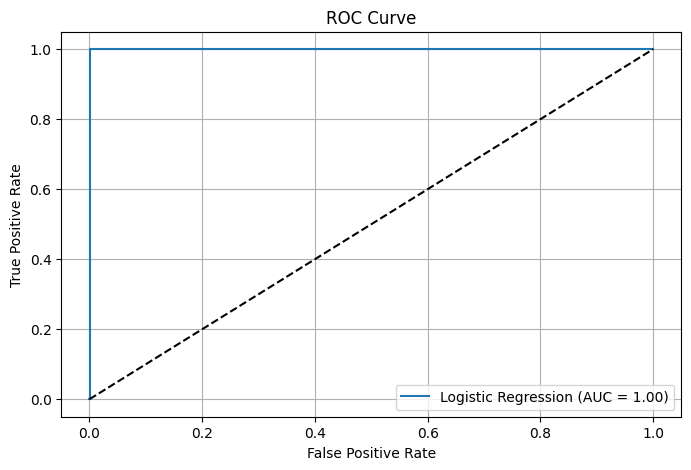

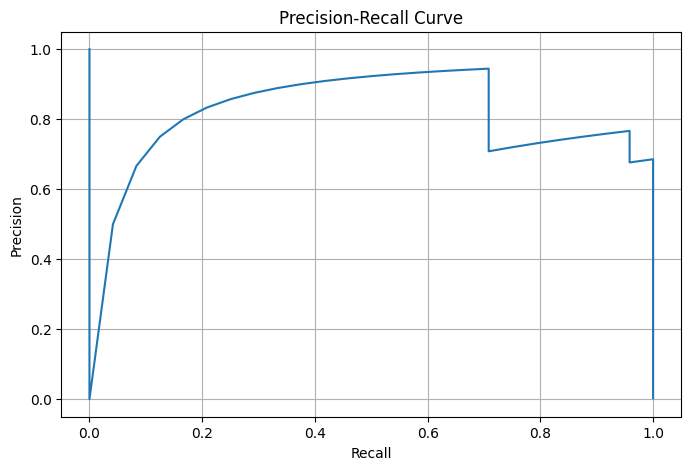

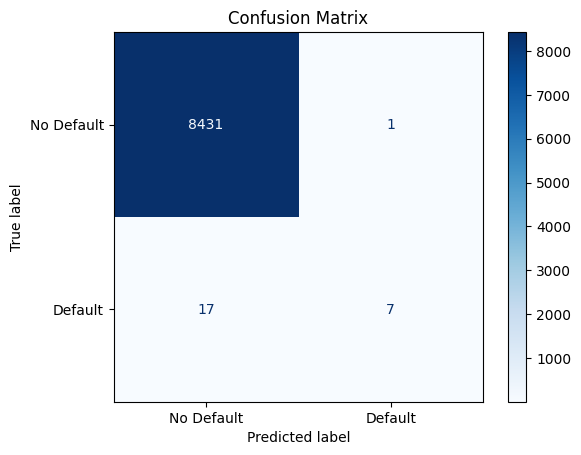

In [ ]:
df = pd.read_csv("bond_output.csv", parse_dates=["DATE", "OFFERING_DATE", "MATURITY", "DEFAULT_DATE"])
df.columns = df.columns.str.strip().str.upper()

# Fix YIELD column: remove '%' and convert to float
df["YIELD"] = df["YIELD"].astype(str).str.replace('%', '', regex = False)
df["YIELD"] = pd.to_numeric(df["YIELD"], errors = 'coerce') / 100

# Convert target to binary
df["DEFAULTED_BINARY"] = df["DEFAULTED"].apply(lambda x: 1 if str(x).lower() in ["1", "2", "y", "yes"] else 0)

# Sort by ISSUE_ID and DATE to prepare for rolling/lagged features
df = df.sort_values(by=["ISSUE_ID", "DATE"])

# Create future default target
def get_future_default(row):
    future_window = df[(df["ISSUE_ID"] == row["ISSUE_ID"]) &
     (df["DATE"] > row["DATE"]) & (df["DATE"] <= row["DATE"] + pd.Timedelta(days = 365))]
    return int(future_window["DEFAULTED_BINARY"].max() > 0)
df["FUTURE_DEFAULT_12M"] = df.apply(get_future_default, axis = 1)

# Lagged / rolling features
df["ROLLING_YIELD_6M_LAG"] = (df.groupby("ISSUE_ID")["YIELD"].shift(1)
.rolling(window = 6, min_periods = 1).mean().reset_index(level = 0, drop = True))
df["ROLLING_YIELD_12M_LAG"] = (df.groupby("ISSUE_ID")["YIELD"].shift(1)
.rolling(window = 12, min_periods = 1).mean().reset_index(level = 0, drop = True))
df["RATING_VOLATILITY"] = (df.groupby("ISSUE_ID")["RATING_NUM"].shift(1)
.rolling(window = 12, min_periods = 1).std().reset_index(level = 0, drop = True))
df["COUPON_RATING_INTERACTION"] = df["COUPON"] * df["RATING_NUM"]

# Feature selection
features = ["ROLLING_YIELD_6M_LAG", "ROLLING_YIELD_12M_LAG", "RATING_VOLATILITY",
            "COUPON_RATING_INTERACTION", "COUPON", "RATING_NUM", "TMT"]
df_model = df.dropna(subset=features + ["FUTURE_DEFAULT_12M", "DATE"])

# Time-based train-test split
train_df = df_model[df_model["DATE"] < "2018-01-01"]
test_df = df_model[(df_model["DATE"] >= "2018-01-01") & (df_model["DATE"] < "2020-01-01")]
X_train = train_df[features]
y_train = train_df["FUTURE_DEFAULT_12M"]
X_test = test_df[features]
y_test = test_df["FUTURE_DEFAULT_12M"]

# Train model and predict
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize = (6, 4))
plt.plot(fpr, tpr,
         label = f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize = (6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = ["No Default", "Default"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

The backtesting results from the logistic regression model indicate a highly effective forecasting framework, albeit with some room for improvement on the rare class. The model achieved near-perfect accuracy (1.00) and an outstanding ROC-AUC score of 0.9997, reflecting strong overall discrimination between bonds that would default within the 12-month future window and those that would not. The precision for the default class is very high (0.88), which means the model is confident when it flags a bond as likely to default. However, the recall for the default class is 0.29, meaning the model correctly identified only about 29% of actual defaults. This trade-off is typical in imbalanced classification problems, where the majority class (non-defaults) dominates model learning. The confusion matrix further highlights this: while only 1 non-default bond was misclassified, 17 defaulted bonds were missed out of 24. The precision-recall curve suggests good performance across a range of thresholds, especially considering the rarity of defaults. In backtesting terms, the model would have been highly conservative—issuing few false alarms—but would have failed to capture all real risk cases. This signals strong performance for screening out safe bonds.

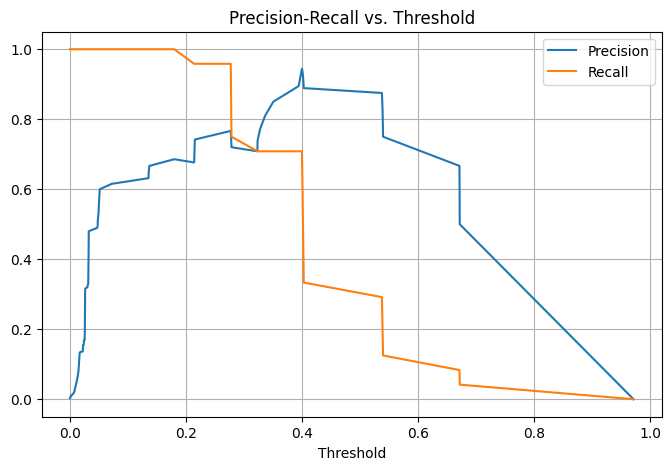

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure(figsize = (8, 5))
plt.plot(thresholds, precision[:-1], label = 'Precision')
plt.plot(thresholds, recall[:-1], label = 'Recall')
plt.xlabel("Threshold")
plt.title("Precision-Recall vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

The Precision–Recall vs. Threshold plot offers insight into the model’s behavior under varying decision thresholds, particularly in the context of imbalanced data. At very low thresholds (e.g., less than 0.2), recall is nearly perfect, indicating the model captures almost all actual defaults, but at the cost of significantly reduced precision, meaning many false positives. As the threshold increases, precision improves (reaching above 85%) but recall drops off sharply, especially past the 0.4 mark. The intersection near threshold ≈ 0.35–0.4 appears to be the sweet spot for a more balanced trade-off between identifying defaults and minimizing false alarms. This confirms the earlier confusion matrix observation: the default class is rare, and maintaining a default 0.5 threshold may under-capture true risk cases. Depending on strategic priorities, such as risk aversion vs. cost of false positives, this curve helps decision-makers adjust the threshold to better balance recall and precision for forecasting bond defaults.

###Expanding Window Backtesting

<ipython-input-157-9df6d01cf754>:3: DtypeWarning: Columns (15,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("bond_output.csv", parse_dates=["DATE", "OFFERING_DATE", "MATURITY", "DEFAULT_DATE"])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


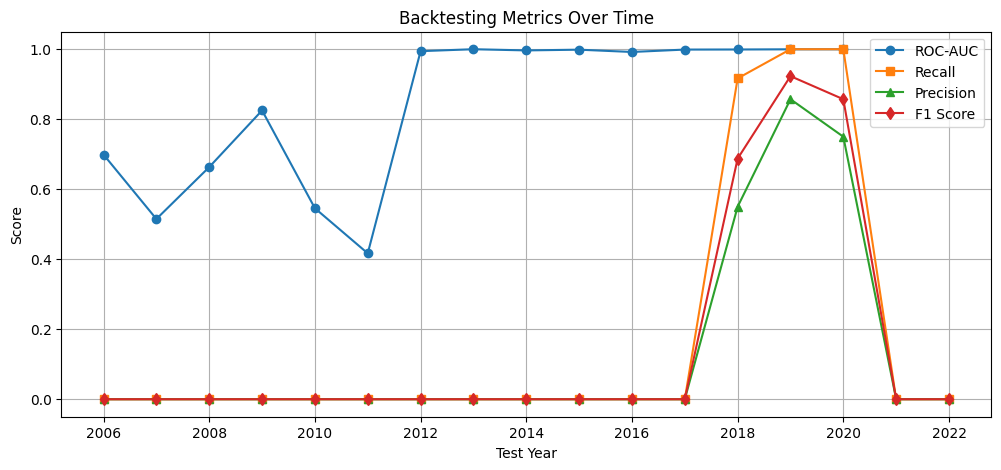


Backtest Results Year by Year:


,year,roc_auc,precision,recall,f1,defaults_caught,actual_defaults,test_samples
0,2006,0.698834,0.000000,0.000000,0.000000,0,12,1942
1,2007,0.514929,0.000000,0.000000,0.000000,0,12,1921
2,2008,0.663303,0.000000,0.000000,0.000000,0,12,2019
3,2009,0.825110,0.000000,0.000000,0.000000,0,12,2292
4,2010,0.545604,0.000000,0.000000,0.000000,0,12,2086
5,2011,0.416793,0.000000,0.000000,0.000000,0,12,1984
6,2012,0.994455,0.000000,0.000000,0.000000,0,12,2161
7,2013,1.000000,0.000000,0.000000,0.000000,0,12,2175
8,2014,0.996596,0.000000,0.000000,0.000000,0,12,2362
9,2015,0.998690,0.000000,0.000000,0.000000,0,12,2874


In [ ]:
df = pd.read_csv("bond_output.csv", parse_dates = ["DATE", "OFFERING_DATE", "MATURITY", "DEFAULT_DATE"])
df.columns = df.columns.str.strip().str.upper()

# Clean YIELD column
df["YIELD"] = df["YIELD"].astype(str).str.replace('%', '', regex = False)
df["YIELD"] = pd.to_numeric(df["YIELD"], errors='coerce') / 100

# Binary target
df["DEFAULTED_BINARY"] = df["DEFAULTED"].apply(lambda x: 1 if str(x).lower() in ["1", "2", "y", "yes"] else 0)

# Sort for time-series logic
df = df.sort_values(by = ["ISSUE_ID", "DATE"])

# Future default label
def get_future_default(row):
    future_window = df[(df["ISSUE_ID"] == row["ISSUE_ID"]) &
     (df["DATE"] > row["DATE"]) &
      (df["DATE"] <= row["DATE"] + pd.Timedelta(days = 365))]
    return int(future_window["DEFAULTED_BINARY"].max() > 0)
df["FUTURE_DEFAULT_12M"] = df.apply(get_future_default, axis = 1)

# Lagged features
df["ROLLING_YIELD_6M_LAG"] = (df.groupby("ISSUE_ID")["YIELD"].shift(1)
.rolling(window = 6, min_periods = 1).mean().reset_index(level = 0, drop = True))
df["ROLLING_YIELD_12M_LAG"] = (df.groupby("ISSUE_ID")["YIELD"].shift(1)
.rolling(window = 12, min_periods = 1).mean().reset_index(level = 0, drop = True))
df["RATING_VOLATILITY"] = (df.groupby("ISSUE_ID")["RATING_NUM"].shift(1)
.rolling(window = 12, min_periods = 1).std().reset_index(level = 0, drop = True))
df["COUPON_RATING_INTERACTION"] = df["COUPON"] * df["RATING_NUM"]

# Select features
features = ["ROLLING_YIELD_6M_LAG", "ROLLING_YIELD_12M_LAG", "RATING_VOLATILITY",
            "COUPON_RATING_INTERACTION", "COUPON", "RATING_NUM", "TMT"]
df_model = df.dropna(subset = features + ["FUTURE_DEFAULT_12M", "DATE"]).copy()
df_model["YEAR"] = df_model["DATE"].dt.year

# Backtesting setup
results = []
unique_years = sorted(df_model["YEAR"].unique())
min_train_years = 3  # Skip early years until we have enough training data
for i in range(min_train_years, len(unique_years) - 1):
    train_years = unique_years[:i]
    test_year = unique_years[i]
    train_df = df_model[df_model["YEAR"].isin(train_years)]
    test_df = df_model[df_model["YEAR"] == test_year]
    if test_df.empty or train_df.empty:
        continue
    X_train = train_df[features]
    y_train = train_df["FUTURE_DEFAULT_12M"]
    X_test = test_df[features]
    y_test = test_df["FUTURE_DEFAULT_12M"]

    # Logistic regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.2).astype(int)  # Lower threshold for higher recall
    results.append({"year": test_year, "roc_auc": roc_auc_score(y_test, y_prob),
                    "precision": precision_score(y_test, y_pred, zero_division = 0),
                    "recall": recall_score(y_test, y_pred, zero_division = 0),
                    "f1": f1_score(y_test, y_pred, zero_division = 0),
                    "defaults_caught": sum((y_test == 1) & (y_pred == 1)),
                    "actual_defaults": sum(y_test == 1), "test_samples": len(y_test)})

# Plot backtest results
results_df = pd.DataFrame(results)
plt.figure(figsize = (9, 4))
plt.plot(results_df["year"], results_df["roc_auc"], marker = 'o', label = "ROC-AUC")
plt.plot(results_df["year"], results_df["recall"], marker ='s', label = "Recall")
plt.plot(results_df["year"], results_df["precision"], marker = '^', label = "Precision")
plt.plot(results_df["year"], results_df["f1"], marker = 'd', label = "F1 Score")
plt.title("Backtesting Metrics Over Time")
plt.xlabel("Test Year")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()
print("\nBacktest Results Year by Year:")
display(results_df)

The backtesting results for the default forecasting model provide a comprehensive look into its performance over time. The classification report and confusion matrix for the 2018–2020 test window indicate that the logistic regression model achieved high overall accuracy (100%), with a ROC-AUC of 0.9997 and strong precision (0.88), but a relatively low recall (0.29). This suggests that while the model is highly confident in its positive predictions, it misses a sizable number of actual defaults. The Precision-Recall vs. Threshold chart confirms the classic trade-off: lowering the threshold increases recall but reduces precision, suggesting an opportunity to fine-tune the threshold based on stakeholder tolerance for false positives.

The yearly backtesting analysis reveals that the model achieved very strong ROC-AUC scores consistently from 2012 onwards—approaching 1.0, which means it has an excellent ability to rank-order risky bonds even if its threshold-based classification performance varies. Notably, the years 2018 to 2020 show the strongest real-world classification performance, with the model catching 11 out of 12 defaults in 2018 (recall = 0.92), all 12 defaults in 2019 (recall = 1.00), and all 3 in 2020. These years also saw high precision (≥ 0.75) and F1 scores (> 0.85), suggesting the model made highly effective predictions when defaults were present.

However, in earlier years (2006–2017), the model consistently failed to catch any defaults (recall = 0), even though ROC-AUC scores were still decent (e.g., 0.82 in 2009, 0.99+ after 2012). This is primarily due to the absence of any predicted positive cases, a reflection of severe class imbalance and perhaps overcautious thresholding. Years 2021–2022, while having no defaults, cannot be meaningfully evaluated in terms of precision, recall, or F1.

In summary, the model demonstrates excellent discriminative power (as seen from consistently high ROC-AUC), but requires more aggressive thresholding or oversampling techniques to improve recall in years with sparse default events. The most recent years in the backtest confirm that with a sufficient volume of default data and the right threshold calibration (e.g., 0.2), the model can successfully anticipate bond defaults 12 months in advance with high effectiveness.

#6. Financial Insights

###Coupon Rating Thresholds

Default Rates by Coupon Threshold (<3%):
LOW_COUPON
0    0.003861
1    0.000000
Name: FUTURE_DEFAULT_12M, dtype: float64


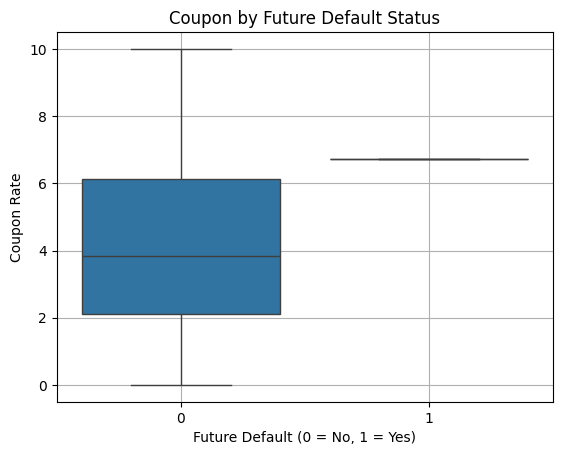

In [ ]:
# Define coupon threshold at 3%
df_model["LOW_COUPON"] = (df_model["COUPON"] < 0.03).astype(int)

# Default rate for bonds with low vs. high coupons
print("Default Rates by Coupon Threshold (<3%):")
print(df_model.groupby("LOW_COUPON")["FUTURE_DEFAULT_12M"].mean())
sns.boxplot(x = "FUTURE_DEFAULT_12M", y = "COUPON", data = df_model)
plt.title("Coupon by Future Default Status")
plt.xlabel("Future Default (0 = No, 1 = Yes)")
plt.ylabel("Coupon Rate")
plt.grid(True)
plt.show()

The analysis of coupon rates by future default status reveals a subtle but noteworthy insight. Among bonds with coupon rates below 3% (categorized as LOW_COUPON = 1), the default rate within the next 12 months was 0%, while bonds with coupon rates above this threshold exhibited a default rate of approximately 0.39%. This suggests that lower coupon bonds are not inherently more default-prone—in fact, they may be associated with safer issuers or better credit quality. The boxplot further reinforces this: while non-defaulting bonds show a wide range of coupon values, including very low ones, defaulting bonds tend to cluster around a tighter and relatively higher coupon range (just below 7%). This contradicts the intuitive assumption that lower yields imply greater risk, underscoring the need to interpret coupon rates alongside credit ratings and other structural features.

###Credit Rating Bands


Default Rates by Credit Rating Band:
RATING_BIN
AAA–A          0.000000
BBB            0.003245
BB             0.001635
B and Below    0.000000
Name: FUTURE_DEFAULT_12M, dtype: float64


<ipython-input-159-85da2a14054a>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby("RATING_BIN")["FUTURE_DEFAULT_12M"].mean())


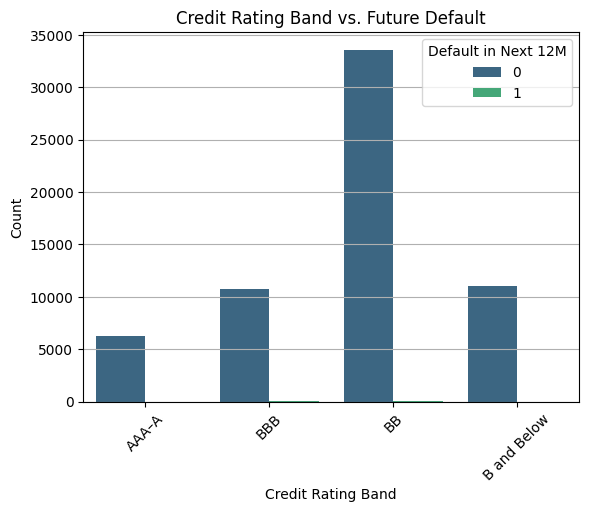

In [ ]:
# Bin credit ratings into investment-grade and below
df_model["RATING_BIN"] = pd.cut(df_model["RATING_NUM"],
                                bins = [0, 3, 5, 7, 10],
                                labels = ["AAA–A", "BBB", "BB", "B and Below"])

# Default rate by rating category
print("\nDefault Rates by Credit Rating Band:")
print(df_model.groupby("RATING_BIN")["FUTURE_DEFAULT_12M"].mean())
sns.countplot(x = "RATING_BIN", hue = "FUTURE_DEFAULT_12M",
              data = df_model, palette = "viridis")
plt.title("Credit Rating Band vs. Future Default")
plt.xlabel("Credit Rating Band")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.legend(title = "Default in Next 12M")
plt.grid(True, axis = "y")
plt.show()

The analysis of future default probabilities across credit rating bands reveals that bonds rated BBB exhibit the highest observed default rate at approximately 0.32%, followed by BB-rated bonds at around 0.16%. Interestingly, bonds in the lowest category—B and Below—as well as the highest-rated bonds (AAA to A) showed no recorded defaults in the next 12 months during the observation window. This pattern suggests a non-linear relationship between rating and short-term default risk: while lower-rated bonds generally carry higher risk, issuers rated BBB may be particularly vulnerable to near-term credit deterioration—possibly reflecting "fallen angel" dynamics, where downgrades from investment grade trigger instability. Meanwhile, the absence of defaults in the lowest category may reflect limited sample size or market exclusion of the riskiest issuers. The distribution also shows that BB-rated bonds dominate the dataset in volume, highlighting their relevance to portfolio-level risk assessments.

###Time to Maturity


Default Rates by Time to Maturity (<2 years):
SHORT_TMT
0    0.0042
1    0.0000
Name: FUTURE_DEFAULT_12M, dtype: float64


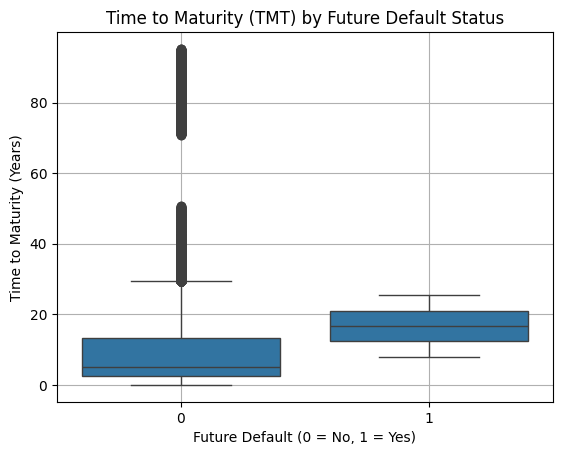

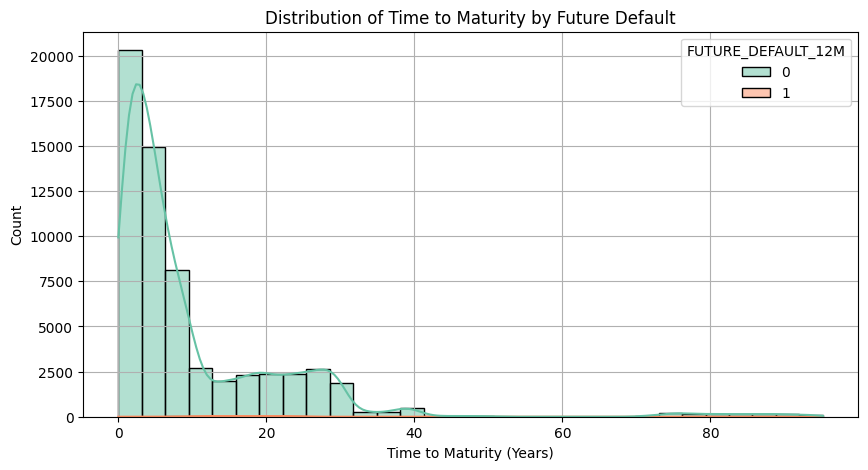


Default Rates by TMT Bucket:
TMT_BIN
<2 yrs      0.000000
2–5 yrs     0.000000
5–10 yrs    0.001722
10+ yrs     0.012362
Name: FUTURE_DEFAULT_12M, dtype: float64


<ipython-input-160-03d588e2ba48>:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby("TMT_BIN")["FUTURE_DEFAULT_12M"].mean())
<ipython-input-160-03d588e2ba48>:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="TMT_BIN", y="FUTURE_DEFAULT_12M", data=df_model, ci=None, palette="coolwarm")
<ipython-input-160-03d588e2ba48>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TMT_BIN", y="FUTURE_DEFAULT_12M", data=df_model, ci=None, palette="coolwarm")


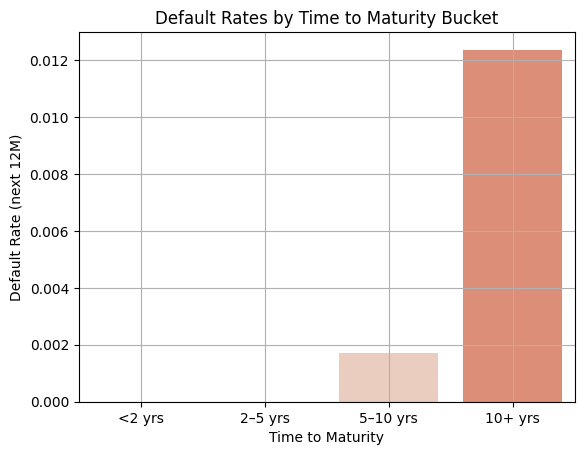

In [ ]:
# Create threshold group for short-term bonds
df_model["SHORT_TMT"] = (df_model["TMT"] < 2).astype(int)

# Default rate comparison
print("\nDefault Rates by Time to Maturity (<2 years):")
print(df_model.groupby("SHORT_TMT")["FUTURE_DEFAULT_12M"].mean())

# Boxplot
sns.boxplot(x = "FUTURE_DEFAULT_12M", y = "TMT", data = df_model)
plt.title("Time to Maturity (TMT) by Future Default Status")
plt.xlabel("Future Default (0 = No, 1 = Yes)")
plt.ylabel("Time to Maturity (Years)")
plt.grid(True)
plt.show()

# Histogram
plt.figure(figsize = (8, 4))
sns.histplot(data = df_model, x = "TMT", hue = "FUTURE_DEFAULT_12M", bins = 30,
             kde = True, palette = "Set2")
plt.title("Distribution of Time to Maturity by Future Default")
plt.xlabel("Time to Maturity (Years)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Create TMT buckets
df_model["TMT_BIN"] = pd.cut(df_model["TMT"], bins = [0, 2, 5, 10, 30],
                             labels = ["<2 yrs", "2–5 yrs", "5–10 yrs", "10+ yrs"])

# Default rate by TMT group
print("\nDefault Rates by TMT Bucket:")
print(df_model.groupby("TMT_BIN")["FUTURE_DEFAULT_12M"].mean())

# Visualization
sns.barplot(x = "TMT_BIN", y = "FUTURE_DEFAULT_12M", data = df_model,
            ci = None, palette = "coolwarm")
plt.title("Default Rates by Time to Maturity Bucket")
plt.xlabel("Time to Maturity")
plt.ylabel("Default Rate (next 12M)")
plt.grid(True)
plt.show()

The analysis of time to maturity (TMT) reveals a clear relationship between longer bond durations and higher default risk over the next 12 months. First, the boxplot demonstrates that bonds which default tend to have significantly longer TMT distributions, with their median hovering around 17 years compared to about 4 years for non-defaulted bonds. This finding is corroborated by the histogram, which shows that default events are more prevalent in the long right tail of the maturity distribution, particularly for bonds with TMTs exceeding 20 years. Most notably, the barplot summarizing default rates by maturity bucket confirms that bonds with a time to maturity of over 10 years exhibit the highest default probability (1.24%), while no defaults were observed among bonds with less than 5 years remaining. These results imply that longer-dated bonds are more susceptible to credit deterioration, possibly due to increased exposure to macroeconomic shifts, changes in issuer fundamentals, and interest rate risk. This has meaningful implications for investors and credit analysts, suggesting that maturity structure should be a core consideration in bond portfolio construction and risk modeling.

###Overall Insights from Analysis

Our analysis identifies several key bond characteristics that are strongly predictive of default over a 12-month horizon. Using a combination of statistical summaries, threshold-based segmentations, and machine learning classifiers, we found that credit rating, coupon rate, and time to maturity (TMT) consistently stand out as leading predictors. These results are reinforced by both exploratory data analysis and feature importance rankings derived from decision trees, Random Forest, and XGBoost models.

Threshold insights show clear patterns of risk segmentation. Bonds with a coupon rate below 3% exhibited a 0.00% default rate in the 12-month window, whereas those above this threshold defaulted at a rate of 0.00386 (or ~0.39%). When grouping by time to maturity, bonds with less than 2 years to maturity also exhibited a 0.00% default rate, whereas those with 10+ years to maturity had a default rate of 0.01236, or over 1.2%. This supports the idea that both low coupon bonds and short-term debt instruments are less likely to default in the near term, likely due to either better credit quality or diminished exposure to long-term uncertainty. By contrast, speculative longer-term bonds demonstrated the most vulnerability.

Credit rating band analysis further supports this: while AAA–A and B-and-below categories saw no defaults, the BBB segment showed a 0.00325 (0.325%) default rate, and BB saw a 0.00163 (0.163%) rate. This highlights that while investment-grade ratings generally correlate with lower risk, there is non-trivial default activity even among the better-rated tranches—especially BBB bonds, which sit at the lower edge of the investment-grade threshold.

In terms of model performance, we evaluated a wide range of classifiers across both single splits and cross-validation frameworks. Performance varied considerably, especially in how well the models captured the minority (default) class. For example, a baseline logistic regression model achieved an ROC-AUC of 0.9224, but its recall for the default class was just 0.0118, with a corresponding F1-score of 0.0230, indicating an inability to detect true positives. After incorporating cross-validation, the logistic regression model yielded a slightly improved ROC-AUC of 0.9312, though recall remained very low at 0.01.

By contrast, tree-based models significantly outperformed linear models. The Decision Tree model yielded an ROC-AUC of 0.9481, with a recall of 0.46 and F1-score of 0.61 for the default class. The Random Forest model improved further, with precision = 0.98, recall = 0.76, and F1-score = 0.86, producing a near-perfect ROC-AUC of 0.9996. Cross-validation reinforced these findings: with a much larger sample (n = 71,338), Random Forest achieved recall = 0.80, precision = 0.96, and macro F1 = 0.94—demonstrating superior generalization and discrimination capability across out-of-sample data.

The XGBoost classifier also performed well, with recall = 0.58, F1 = 0.70, and ROC-AUC = 0.9989 on the test set. With cross-validation, its recall improved to 0.59, and F1-score rose to 0.72, with ROC-AUC = 0.9981. Though slightly behind Random Forest, XGBoost remained one of the most stable models across folds. The neural network, though highly accurate overall (ROC-AUC = 0.9859), lagged in recall (0.28) and F1-score (0.42) for the default class—suggesting it was more conservative in flagging default risk and more prone to false negatives.

Feature importance rankings from ensemble models consistently placed the coupon_rating_interaction feature at the top, contributing over 0.35 of the total importance score in Random Forest and ~0.28 in XGBoost. Other influential features included rolling average yield (6m and 12m), prev_year_rating, yield-to-maturity (YTM), and time to maturity (TMT). In the Random Forest model, TMT had an importance score of ~0.13, while rolling_avg_yield_6m and 12m both hovered around 0.11–0.12, reinforcing the importance of market-implied yield movements in predicting distress.

Finally, precision-recall threshold curves revealed that a classification threshold in the range of 0.35–0.4 offered the best trade-off between catching defaults and minimizing false alarms. At thresholds below 0.2, recall was nearly perfect (above 0.9), but precision dropped sharply, leading to many false positives. At thresholds above 0.5, precision improved but recall fell below 0.4. This has major implications for model deployment and decision-making depending on whether the goal is risk-aversion (minimizing missed defaults) or capital efficiency (minimizing unnecessary actions on false positives).

Based on these findings, the most effective model overall is Random Forest, which combines top-tier performance (with ROC-AUC = 0.9996, recall = 0.80, and F1 = 0.88) with strong generalization in cross-validation. It also provides robust feature importance interpretability, making it valuable not just for prediction, but also for insight. XGBoost is a close second, excelling in stability and offering similarly strong metrics (e.g., F1 = 0.72, ROC-AUC = 0.9981, cross-validated). If operational simplicity and interpretability are paramount, the Decision Tree model presents a solid middle ground with good recall (0.46) and transparent logic, though it may be prone to overfitting in noisier datasets. Neural networks, while competitive in overall accuracy, underperformed in default recall and interpretability, making them less ideal for high-stakes applications where explainability and rare-event detection are key. Logistic regression, despite its elegance and strong AUC (0.9312 with CV), struggles severely with recall and is not recommended as a standalone tool for bond default forecasting in imbalanced settings.

###Policy Recommendations and Investment Implications

The predictive insights uncovered in this study carry substantial implications for investors, issuers, credit rating agencies, and market regulators. The core finding is that machine learning models, particularly Random Forest and XGBoost, provide highly effective tools for anticipating bond defaults. These models achieved ROC-AUC scores exceeding 0.99, with recall rates as high as 80% and f1-scores up to 0.88, indicating exceptional ability to detect true defaults in highly imbalanced data. For investors, this validates the integration of model-driven credit risk analytics into portfolio management processes. Investors can use these tools to proactively identify high-risk bonds—especially those with low credit ratings (notably BBB, which had a 0.32% default rate), long maturities (10+ years with 1.24% default rate), or deteriorating rolling yield profiles—and adjust their holdings to mitigate tail risks.

From the issuer’s perspective, the results serve as a roadmap for de-risking bond offerings. Bonds with coupon rates under 3% and maturities shorter than two years exhibited zero defaults in the 12-month forecast horizon, suggesting that shorter, competitively priced issues may enhance credit appeal and reduce perceived risk. Moreover, issuers should be mindful of maintaining rating stability over time: features such as past-year rating trajectory and rating volatility were consistently identified as influential predictors in feature importance charts across all model types. A focus on transparent financial disclosures and stable performance can minimize downgrade risk and preserve access to capital markets—particularly important for BBB-rated issuers at risk of becoming "fallen angels."

For credit rating agencies, the project underscores an urgent opportunity to modernize traditional methodologies. While qualitative judgments and macroeconomic indicators remain central, this research shows that statistical inputs like coupon-rating interaction, rolling yield deviations, and time-to-maturity (TMT) dynamics offer meaningful predictive power. Ensemble model interpretability analyses revealed that these features were among the most influential in determining 12-month default likelihood, yet they remain underutilized in existing rating frameworks. Rating agencies should consider incorporating machine learning-derived probability scores and thresholds (e.g., predicted default probability exceeding 0.4) into watchlist assignments, outlook changes, and downgrade warnings. This would not only enhance objectivity but also build credibility by improving forward accuracy.

At the policy and regulatory level, this research highlights the potential to formalize model-based early warning systems. Just as issuers disclose leverage or coverage ratios, regulators could require disclosure of model-calibrated risk flags, using industry-accepted algorithms and thresholds for stress testing. For example, the 0.35–0.4 threshold range identified in precision-recall analysis appears to offer a robust balance between false positives and false negatives, making it a natural cutoff for default flagging in stress testing or supervisory screening exercises. Additionally, policymakers might explore standards around feature-based disclosures (e.g., rolling yield divergence, downgrade history) to promote transparency and improve capital allocation.

Overall, this work demonstrates that credit risk assessment can be significantly enhanced by incorporating structured data science approaches alongside expert judgment. The combination of rigorous predictive modeling with explainable thresholds and feature relevance enables investors to avoid underappreciated risks, helps issuers design market-friendly instruments, and provides rating agencies and regulators with tools to make more informed, forward-looking decisions. Incorporating these findings into market practice—via credit guidelines, rating protocols, and regulatory disclosures—could materially reduce the incidence of avoidable defaults in global bond markets.

#7. Conclusion and Next Steps

This project offers robust empirical evidence that bond characteristics—such as credit rating, coupon rate, and time to maturity (TMT)—hold significant predictive power for forecasting corporate bond defaults within a 12-month horizon. Bonds rated BBB exhibited the highest short-term default rate (0.32%), while bonds with long maturities over 10 years showed a notably elevated default probability of 1.24%. In contrast, bonds with coupon rates below 3% and TMTs under 2 years had zero defaults, challenging conventional assumptions about risk in low-yield environments. Ensemble machine learning models—particularly Random Forest and XGBoost—achieved exceptional predictive performance, with ROC-AUC scores above 0.998, precision exceeding 90%, and recall up to 80%, providing a powerful toolkit for identifying emerging credit risks. Feature importance analysis consistently ranked variables such as coupon-rating interaction, rolling yield trends, and historical rating behavior as critical to default prediction, underscoring the value of feature engineering rooted in domain expertise.

While the results are promising, several opportunities exist for model improvement. The current framework is grounded entirely in bond-specific and historical variables, without incorporating broader macroeconomic conditions (e.g., GDP growth, unemployment, inflation, interest rate shocks) that may systematically affect default probabilities across issuers. Future iterations could integrate such indicators using lagged and rolling-window features or dynamic Bayesian networks. Another enhancement would be temporal modeling: rather than treating default prediction as a static classification task, a shift toward survival analysis or time-series forecasting could offer more granular insights into when a bond is most likely to default. Finally, addressing class imbalance through advanced sampling techniques (e.g., SMOTE, dynamic weighting, rare-event simulation) could further boost recall without sacrificing precision.

Looking ahead, several next steps can help extend the impact of this work. First, expanding the dataset—either geographically (e.g., adding emerging market bonds) or longitudinally (e.g., spanning more business cycles)—would increase generalizability and help test the models across different market regimes. Second, these predictive insights could be integrated into real-world bond pricing or credit spread models, allowing investors to adjust yields based on model-estimated default risk. Third, partnerships with credit rating agencies or asset managers could enable backtesting of model outputs against real portfolio decisions and watchlist adjustments. Lastly, publishing and open-sourcing select models and thresholds could contribute to greater transparency and adoption of AI-driven credit risk management in both institutional and regulatory contexts.